<details>
  <summary><strong>MIT License (クリックで展開)</strong></summary>

  <pre>
MIT License
Copyright (c) 2023 AI Course Notebook Contributors
Repository: https://github.com/arch-inform-kaken-group/ai-course-notebooks

Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files (the "Software"), to deal
in the Software without restriction, including without limitation the rights
to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
copies of the Software, and to permit persons to whom the Software is
furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all
copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,
OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE
SOFTWARE.
  </pre>
</details>

# セマンティックセグメンテーション（U-Net）による路上障害物検出
今回のハンズオンは，セマンティックセグメンテーションがどのようなものかを体感していただくことが目標です．


## セマンティクセグメンテーションとは


セマンティックセグメンテーション（Semantic Segmentation）は領域分類/領域分割とも呼ばれ，画像のピクセル（画素）1個1個に対しラベルを付与し，画素単位で被写体のタグ付け（分類）を行います．

バウンディングボックス検出と比較した場合，不定形の領域（例：空など）にもラベルを付与可能であることが利点として挙げられます．

自動運転車両・レントゲン等の医用画像など，被写体を識別する場面などで活用されている技術です．

セグメンテーションのイメージ例：

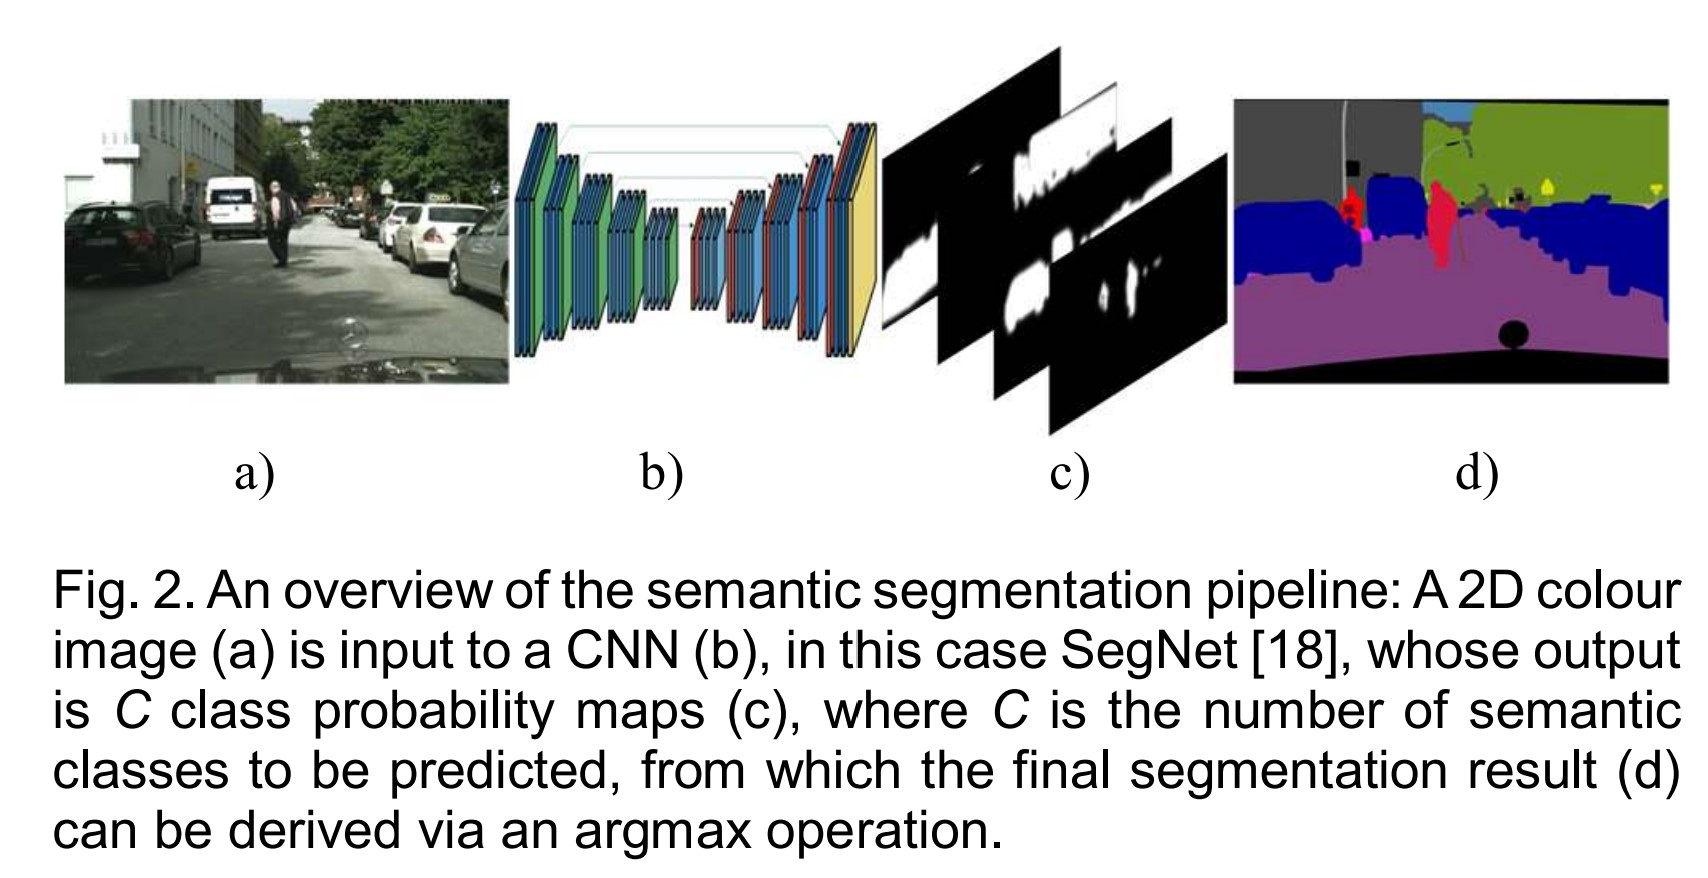

---

画像引用元：

On Efficient Real-Time Semantic Segmentation: A Survey  (Jun. 19, 2023, 09:45 UTC). In arXiv:The Open Access Eprint Archive. Retrieved from https://arxiv.org/abs/2206.08605



## GPU の利用確認とTensorFlowのバージョン確認

In [ ]:
!nvidia-smi

Tue Jun 27 04:54:41 2023       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 525.85.12    Driver Version: 525.85.12    CUDA Version: 12.0     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla T4            Off  | 00000000:00:04.0 Off |                    0 |
| N/A   56C    P8    11W /  70W |      0MiB / 15360MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

In [ ]:
import tensorflow as tf
import sklearn

print('TensorFlow version:',tf.__version__)
print('scikit-learn version:',sklearn.__version__)

if tf.__version__ != '2.12.0':
    !pip install -q --upgrade tensorflow==2.12.0
    print('TensorFlow version:',tf.__version__)

if sklearn.__version__ != '1.2.2':
    !pip install -q --upgrade scikit-learn==1.2.2
    print('scikit-learn version:',sklearn.__version__)

TensorFlow version: 2.12.0
scikit-learn version: 1.2.2


### 外部ライブラリのインストール


In [ ]:
!pip install -qU segmentation-models #セグメンテーション用のモデルを簡単に実装できるライブラリ
!pip install -q japanize_matplotlib # matplotlib日本語化用ライブラリ

### ライブラリインポート

In [ ]:
import os # os：標準ライブラリ，OS依存の処理（環境変数やフォルダ作成など）を扱う
import datetime # datetime：標準ライブラリ，日付関連データを扱う
import random # random：標準ライブラリ，擬似乱数発生器
import numpy as np # numpy：数値計算用ライブラリの一つ
import pandas as pd # pandas：表計算用ライブラリの一つ
from IPython.display import display # Colabなどで一部のデータをprint()よりも綺麗に出力できる関数
import glob # glob:パスを扱う標準ライブラリ

import matplotlib.pylab as plt # matplotlib：グラフ描画用ライブラリの一つ
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap


import seaborn as sns # seaborn：グラフ描画用ライブラリの一つ
# tensorboard：深層学習ライブラリTensorFlowのダッシュボード出力用設定
#%load_ext tensorboard
import tensorflow as tf # TensorFlow：深層学習ライブラリ一つ

import japanize_matplotlib # matplotlib日本語化用の外部ライブラリ

import tensorflow_datasets as tfds # TensoFlow datasets TensorFlow が提供するデータセット群が纏められたライブラリ
os.environ["SM_FRAMEWORK"] = "tf.keras" # segmentation_modelsで使用するライブラリをTensorFlow内蔵のKerasとする
import segmentation_models as sm #セグメンテーション用のモデルを簡単に実装できるライブラリ


Segmentation Models: using `tf.keras` framework.



今回は下記の擬似乱数シード固定を**行わない**．<br>
（GPU上での決定論的動作に対応していない処理が含まれるため．）
```python
def set_seed(seed=123):
    # hash seed の固定
    os.environ["PYTHONHASHSEED"] = str(seed)
    # Python外部ライブラリ：TensorFlow の ニューラルネットワークを決定論的に動作させる
    os.environ['TF_DETERMINISTIC_OPS'] = 'true'
    # Python外部ライブラリ：TensorFlow の ニューラルネットワークを決定論的に動作させる
    os.environ['TF_CUDNN_DETERMINISTIC'] = 'true'
    # Python標準ライブラリ：random の seed固定
    random.seed(seed)
    # Python外部ライブラリ：Numpy の seed固定
    np.random.seed(seed)
    # Python外部ライブラリ：TensorFlow の seed固定
    tf.random.set_seed(seed)
set_seed(42)
```



## データセットの取得

今回のハンズオンで使用するデータセットは [TensorFlow Datasets](https://www.tensorflow.org/datasets/catalog/lost_and_found?hl=en) から入手します．

このデータセット「Lost and Found」は，自動運転車両実現ために道路上の障害物を検出することを目的として作成されました．

----
データセット出典：<br>
［arXiv］ [Lost and Found: Detecting Small Road Hazards for Self-Driving Vehicles](https://arxiv.org/abs/1609.04653)

In [ ]:
# 時間短縮のために，train dataset の先頭 7%，test dataset の先頭2% のみ使用します．
# 約10分
dataset, info = tfds.load('lost_and_found:1.*.*', split={'train':'train[:5%]','valid':'train[5%:7%]','test':'test[:2%]'}, with_info=True)

このデータセットは，本来は下記表のようにマスク領域が定義されていますが，<br>
今回使用するデータは一部分だけなので，大幅に簡略化する処理を行います．


|Label | name ID| trainID| description| category|
|----|----|----|----|----|
|’unlabeled’| 0 |255 | - | Miscellaneous |
|’ego vehicle’| 0 |255 | - | Miscellaneous|
|’rectification border’ |0 |255| -|Miscellaneous|
|’out of roi’ |0| 255| -|Miscellaneous|
|’free’ |1| 1| Free space |Counter hypotheses|
|’background’ |0| 0 | Background |Counter hypotheses|
|’01’ |2 |2 |Crate (black) |Standard objects|
|’02’ |3 |2 |Crate (black - 2x stacked)|Standard objects |
|’03’ |4| 2 |Crate (black - upright)| Standard objects|
|’04’ |5| 2| Crate (gray)| Standard objects|
|’05’ |6| 2 |Crate (gray - 2x stacked)|Standard objects|
|’06’ |7| 2| Crate (gray - upright)|Standard objects|
|’07’ |8 |2| Bumper |Random hazards|
|’08’| 9 |2| Cardboard box| Random hazards|
|’09’ |10| 2 |Crate (blue)| Random hazards|
|’10’| 11| 2 |Crate (blue - small)|Random hazards|
|’11’ |12| 2 |Crate (green)|Random hazards|
|’12’| 13| 2 |Crate (green - small)| Random hazards|
|’13’| 14| 2 |Exhaust pipe| Random hazards|
|’14’ |15 |2 |Headlight |Random hazards|
|’15’ |16| 2 |Euro pallet|Random hazards|
|’16’ |17 |2| Pylon|Random hazards|
|’17’ |18| 2 |Pylon (large)|Random hazards|
|’18’ |19 |2 |Pylon (white)|Random hazards|
|’19’ |20| 2 |Rearview mirror|Random hazards|
|’20’ |21| 2 |Tire|Random hazards|
|’29’ |30 |2| Cardboard box|Random hazards|
|’31’ |32 |2| Plastic bag (bloated)|Random hazards|
|’34’ |35 |2| Styrofoam|Random hazards|
|’21’ |22 |2 |Ball |”Emotional” hazards|
|’22’ |23 |2 |Bicycle|”Emotional” hazards|
|’23’ |24 |2 |Dog (black)|”Emotional” hazards|
|’24’ |25 |2 |Dog (white)|”Emotional” hazards|
|’25’ |26 |2 |Kid Dummy|”Emotional” hazards|
|’26’ |27 |2 |Bobby car (gray)|”Emotional” hazards|
|’27’ |28 |2 |Bobby car (red)|”Emotional” hazards|
|’28’ |29 |2 |Bobby car (yellow)|”Emotional” hazards|
|’30’ |31 |0 |Marker pole (lying) |Random non-hazards|
|’32’ |33 |0 |Post (red - lying)|Random non-hazards|
|’33’ |34 |0 |Post stand|Random non-hazards|
|’35’ |36 |0 |Timber (small)|Random non-hazards|
|’36’ |37 |0 |Timber (squared)|Random non-hazards|
|’37’ |38 |0 |Wheel cap|Random non-hazards|
|’38’ |39 |0 |Wood (thin)|Random non-hazards|
|’39’ |40 |2 |Kid (walking) |Humans|
|’40’ |41 |2 |Kid (on a bobby car)|Humans|
|’41’ |42 |2 |Kid (on a small bobby car)|Humans|
|’42’ |43 |2 |Kid (crawling)|Humans|


## 入力データの調整と生成
時間短縮のために，今回のハンズオンでは正解のマスク領域を下記表のように簡略化します．

|マスク領域の数値ラベル | マスク領域の種別名|
|----|----|
|0 | 背景 |
|1 | 走行可能な領域 |
|2 | 路上障害物 |
|3 | その他 |

また，本来の画像サイズは 高1024×幅2048 ですが，Colab上で訓練させるには画像サイズが大きすぎるため，縮小処理を行います．

In [ ]:

# 使用する画像サイズ
IMG_SIZE_WIDTH = 256 # 元画像は2048
IMG_SIZE_HEIGHT = 128 # 元画像は1024

TRAIN_LENGTH = dataset['train'].cardinality().numpy()
VALID_LENGTH = dataset['valid'].cardinality().numpy()
TEST_LENGTH = dataset['test'].cardinality().numpy()

BATCH_SIZE = 8
BUFFER_SIZE = 10
STEPS_PER_EPOCH = TRAIN_LENGTH // BATCH_SIZE
VALIDATION_STEPS = VALID_LENGTH // BATCH_SIZE

# 数値ラベルと種別名の対応を定義
mask_label_to_category_name = {
    0 : '背景',
    1 : '走行可能な領域',
    2 : '路上障害物',
    3 : 'その他'
}

@tf.function
def mapping(x):
    ###
    # 簡略化のための正解ラベル調整
    ###

    # Standard objects（物体）,
    # Random hazards（走行上危険な異物）,
    # Random non-hazards（走行上危険ではない異物）
    # Emotional hazards（精神上危険な異物 例：ボール/犬/猫）,
    # humans（人）
    #  -> これらを一括して「路上障害物」の扱いとする
    x = tf.where( ( ( x >= 2 ) & ( x <= 43) ), 2, x)

    # miscellaneous (その他)
    x = tf.where( ( x>=255 )&( x<=255 ), 3, x)

    return x

def normalize(input_image, input_mask):

    input_image = tf.cast(input_image, tf.float32) / 255.0
    input_mask = tf.cast(input_mask, tf.int32)

    input_mask = tf.map_fn(fn=mapping, elems=input_mask, fn_output_signature=tf.int32)

    input_mask = tf.reshape(tensor = tf.one_hot(tf.cast(input_mask, tf.int32), depth=len(mask_label_to_category_name), axis=3), \
                            shape = (IMG_SIZE_HEIGHT, IMG_SIZE_WIDTH, len(mask_label_to_category_name)))

    return input_image, input_mask


def load_image(datapoint):

    input_image = tf.image.resize(images = datapoint['image_left'],
                                size = (IMG_SIZE_HEIGHT, IMG_SIZE_WIDTH),
                                method=tf.image.ResizeMethod.BILINEAR
                                )


    input_mask = tf.image.resize(images = datapoint['segmentation_label'],
                                size = (IMG_SIZE_HEIGHT, IMG_SIZE_WIDTH),
                                antialias=False, # NEAREST_NEIGHBOR の場合は無効
                                # A deterministic GPU implementation of ResizeNearestNeighborGrad is not currently available.
                                # GPUの決定論的動作に対応していない画像補間手法ですが，マスク領域の補間にはこの手法を使います．
                                # 他の画像補間手法は隣接する画素値で平均したりするなど，マスク領域の値が意図しない値へ変わるため不適です．
                                method=tf.image.ResizeMethod.NEAREST_NEIGHBOR
                                #method=tf.image.ResizeMethod.BILINEAR #(maskには不適な補間)
                                #method=tf.image.ResizeMethod.BICUBIC #(maskには不適な補間)
                                #method=tf.image.ResizeMethod.AREA #(maskには不適な補間)
                                )

    input_image, input_mask = normalize(input_image, input_mask)
    return input_image, input_mask



train_images = dataset['train'].map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
valid_images = dataset['valid'].map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
test_images = dataset['test'].map(load_image, num_parallel_calls=tf.data.AUTOTUNE)

print(f'入力画像サイズ（幅）{IMG_SIZE_WIDTH}')
print(f'入力画像サイズ（高）：{IMG_SIZE_HEIGHT}')

print(f'訓練用データ数：{TRAIN_LENGTH}')
print(f'検証用データ数：{VALID_LENGTH}')
print(f'テスト用データ数：{TEST_LENGTH}')


入力画像サイズ（幅）256
入力画像サイズ（高）：128
訓練用データ数：52
検証用データ数：21
テスト用データ数：24


画像をランダムに左右反転するデータ拡張を，訓練用データセットにのみ適用します．

In [ ]:
class Augment(tf.keras.layers.Layer):
  def __init__(self, seed=42):
    super().__init__()
    # both use the same seed, so they'll make the same random changes.
    self.augment_inputs = tf.keras.layers.RandomFlip(mode="horizontal", seed=seed)
    self.augment_labels = tf.keras.layers.RandomFlip(mode="horizontal", seed=seed)

  def call(self, inputs, labels):
    inputs = self.augment_inputs(inputs)
    labels = self.augment_labels(labels)
    return inputs, labels



train_dataset = (
    train_images
    #.cache()
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE)
    .repeat()
    .map(Augment())
    .prefetch(buffer_size=tf.data.AUTOTUNE))

valid_dataset = valid_images.batch(BATCH_SIZE).repeat()
test_dataset = test_images.batch(BATCH_SIZE)

画像サンプルと対応するデータセットのマスクを可視化します．

(128, 256, 4)
[0 1 2]


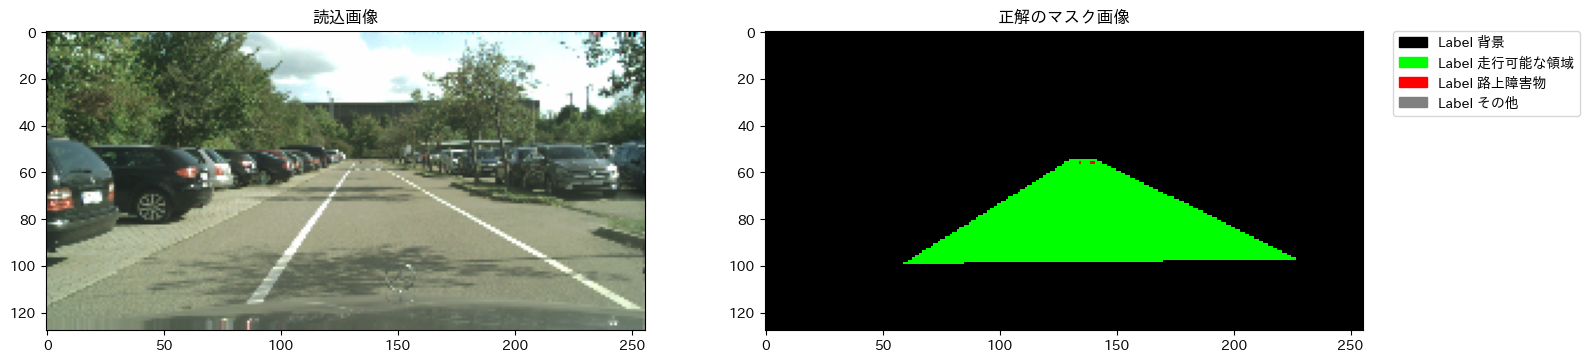

(128, 256, 4)
[0 1 2]


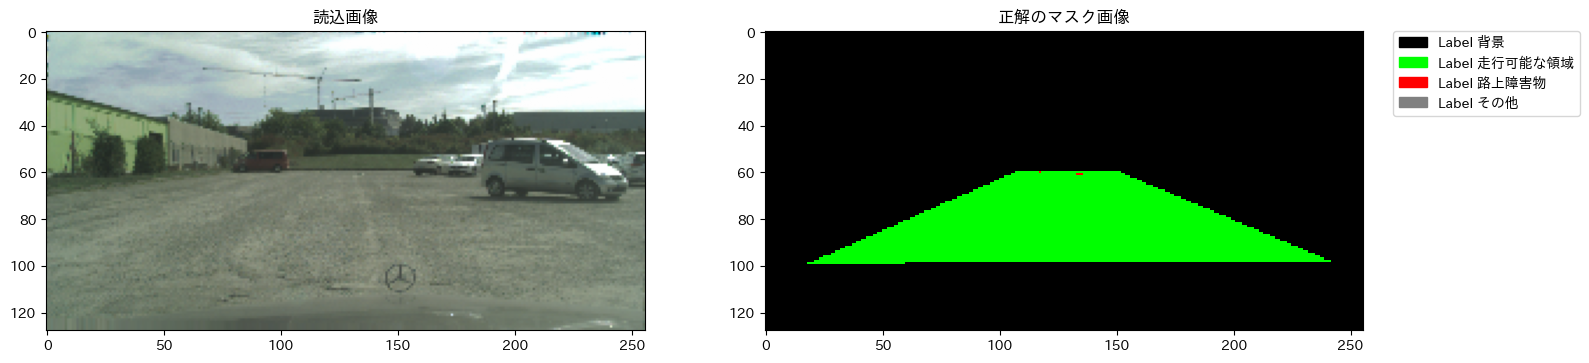

(128, 256, 4)
[0 1]


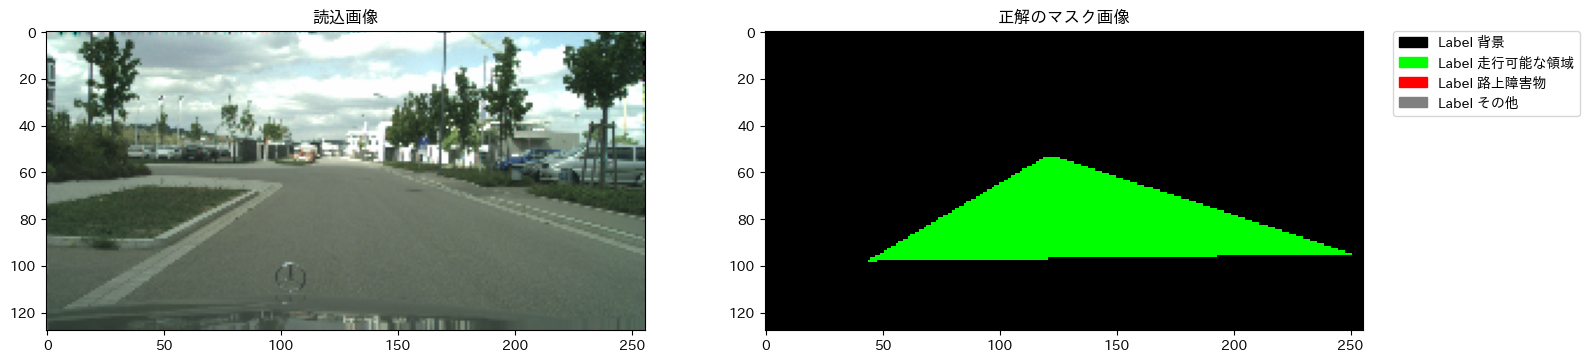

In [ ]:
colors = ['black', 'lime', 'red', 'gray']
cmap = ListedColormap(colors, name="custom")
cmap.set_bad('yellow') #無効な値が出力された場合
values = range(len(mask_label_to_category_name))

for images, masks in train_dataset.take(1):
    # 1バッチ中から先頭3枚を描画
    for n in range(3):

        sample_image, sample_mask = images[n], masks[n]

        print(sample_mask.numpy().shape)

        sample_mask = tf.math.argmax(sample_mask, axis=-1)[..., tf.newaxis]

        fig, axes = plt.subplots(1,2, figsize=(17,10))
        axes[0].imshow(sample_image)
        axes[0].set_title('読込画像')

        print(np.unique(sample_mask.numpy()))

        axes[1].imshow(sample_mask, interpolation = 'none', \
                            cmap = cmap, vmin = np.min(values), vmax = np.max(values))
        axes[1].set_title('正解のマスク画像')

        patches = [ mpatches.Patch(color=colors[i], label="Label {l}".format(l=mask_label_to_category_name[i]) ) for i in range(len(values)) ]
        plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0. )

        plt.show()

## セグメンテーションモデルの構築

使用モデルは修正 [U-Net](https://arxiv.org/abs/1505.04597) です．

U-Net には，エンコーダ（ダウンサンプラー）とデコーダ（アップサンプラー）が含まれます．強力な特徴量を理解してトレーニング可能なパラメータ数を減らすため，事前学習済みモデルをエンコーダとして使用します．

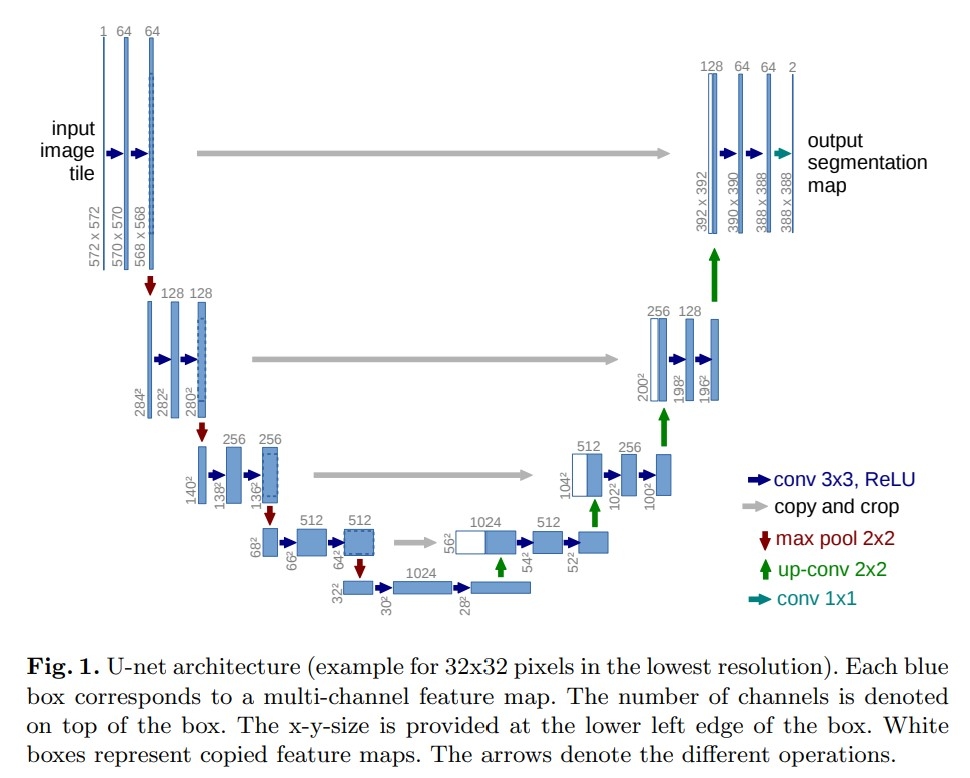

---

画像引用元：

U-Net: Convolutional Networks for Biomedical Image Segmentation (Jun. 19, 2023, 09:45 UTC). In arXiv:The Open Access Eprint Archive. Retrieved from https://arxiv.org/abs/1505.04597


モデルを訓練する前に，モデルが何を出力するかを見てみます．

In [ ]:
# 描画用関数

def create_mask(pred_mask, n=0):
    pred_mask = tf.argmax(pred_mask, axis=-1)
    pred_mask = pred_mask[..., tf.newaxis]
    return pred_mask[n]


def show_predictions(dataset, num=1):

    colors = ['black', 'lime', 'red', 'gray']
    cmap = ListedColormap(colors, name="custom")
    cmap.set_bad('yellow') #無効な値が出力された場合
    values = range(len(mask_label_to_category_name))

    for image, true_mask in dataset.take(1):
        for n in range(num):

            fig, axes = plt.subplots(1, 3, figsize=(17,10))
            axes[0].imshow(image[n])
            axes[0].set_title('読込画像')

            axes[1].imshow(create_mask(true_mask, n=n), interpolation='none', \
                          cmap=cmap, vmin = np.min(values), vmax = np.max(values))
            axes[1].set_title('正解のマスク画像')

            predict_mask = create_mask( model.predict(image), n=n )
            axes[2].imshow(predict_mask, interpolation='none', \
                                cmap=cmap, vmin = np.min(values), vmax = np.max(values))
            axes[2].set_title('モデルにより推定された領域')

            print(np.unique(predict_mask.numpy().ravel()))

            patches = [ mpatches.Patch(color=colors[i], \
                                        label="Label {l}".format(l=mask_label_to_category_name[i]) ) for i in range(len(values)) ]

            plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0. )
            plt.show()

モデルを構築して，未訓練状態の出力を見てみます．

/usr/local/lib/python3.10/dist-packages/keras_applications/mobilenet_v2.py:294: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  warnings.warn('`input_shape` is undefined or non-square, '


1/1 [==============================] - 7s 7s/step
[0 1 2 3]


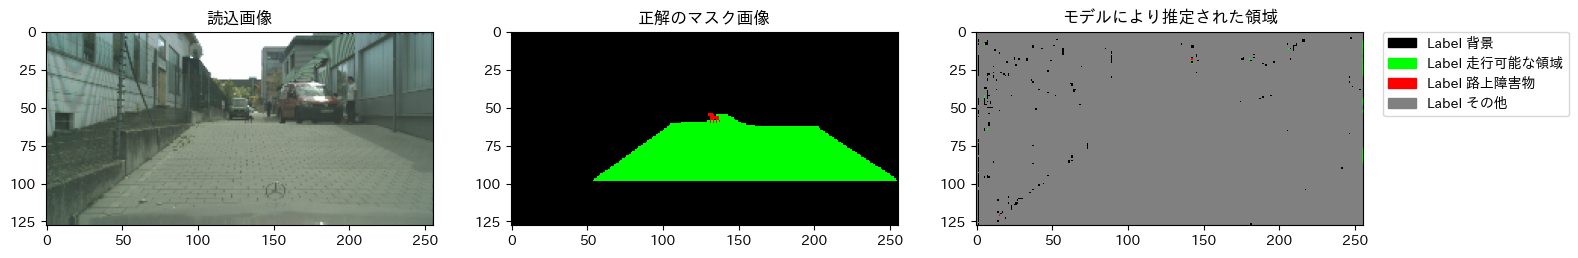

In [ ]:
tf.keras.backend.set_image_data_format('channels_last')

model = sm.Unet('mobilenetv2', classes=len(mask_label_to_category_name), \
                activation='softmax', encoder_weights='imagenet')

model.compile(
    'Adam',
    loss=sm.losses.dice_loss,
    metrics=[sm.metrics.iou_score],
)

show_predictions(test_dataset)

構築されたモデルの構成を簡単に出力します．

In [ ]:
# こちらはPNGファイルに出力
tf.keras.utils.plot_model(model, to_file='unet_model.png', show_shapes=True)

# こちらは下に出力
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, None, None,  0           []                               
                                 3)]                                                              
                                                                                                  
 Conv1_pad (ZeroPadding2D)      (None, None, None,   0           ['input_1[0][0]']                
                                3)                                                                
                                                                                                  
 Conv1 (Conv2D)                 (None, None, None,   864         ['Conv1_pad[0][0]']              
                                32)                                                           

## モデルの訓練

今回は，訓練中にモデルがどのように改善されるかを監視するための```DisplayCallback```を作成します．

In [ ]:
class DisplayCallback(tf.keras.callbacks.Callback):

    def __init__(self, validation_dataset):
        super().__init__()
        self.validation_data = validation_dataset

    def on_epoch_end(self, epoch, logs):
        # 10 Epoch毎に推論画像を出力する
        if (epoch % 10 == 0) :
            show_predictions(self.validation_data)
            print('\nSample Prediction after epoch {}\n'.format(epoch+1))


Epoch 1/100
1/1 [==============================] - 1s 880ms/step
[0 1 2 3]


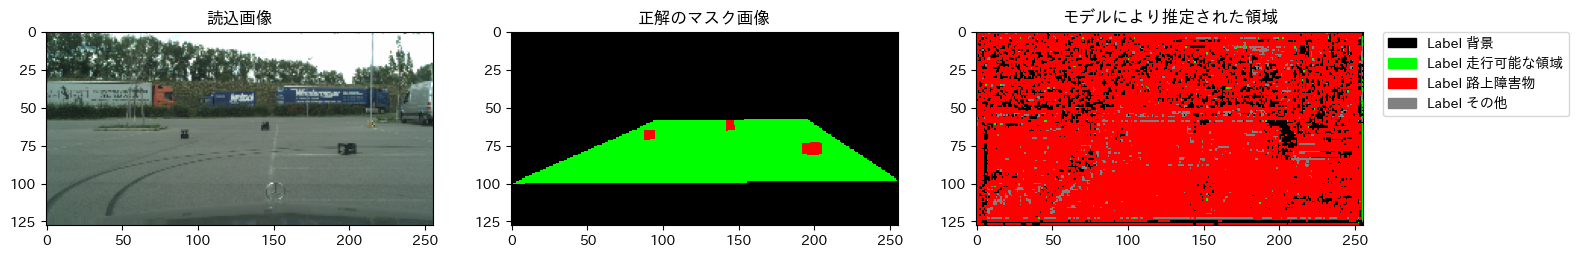


Sample Prediction after epoch 1

6/6 [==============================] - 54s 2s/step - loss: 3.7152 - iou_score: 0.0624 - val_loss: 3.6897 - val_iou_score: 0.0727
Epoch 2/100
6/6 [==============================] - 8s 1s/step - loss: 3.6558 - iou_score: 0.0743 - val_loss: 3.6946 - val_iou_score: 0.0729
Epoch 3/100
6/6 [==============================] - 4s 870ms/step - loss: 3.6006 - iou_score: 0.0863 - val_loss: 3.7081 - val_iou_score: 0.0684
Epoch 4/100
6/6 [==============================] - 3s 633ms/step - loss: 3.5264 - iou_score: 0.1027 - val_loss: 3.7299 - val_iou_score: 0.0607
Epoch 5/100
6/6 [==============================] - 6s 1s/step - loss: 3.4558 - iou_score: 0.1195 - val_loss: 3.4744 - val_iou_score: 0.1059
Epoch 6/100
6/6 [==============================] - 5s 1s/step - loss: 3.3921 - iou_score: 0.1347 - val_loss: 3.2828 - val_iou_score: 0.1341
Epoch 7/100
6/6 [==============================] - 6s 1s/step - loss: 3.3222 - iou_score: 0.1521 - val_loss: 3.2761 - val_iou_score

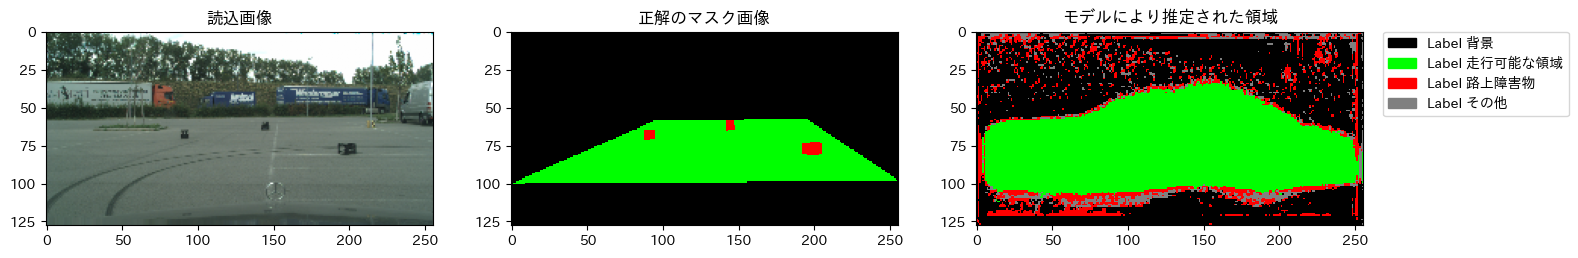


Sample Prediction after epoch 11

6/6 [==============================] - 11s 2s/step - loss: 3.0850 - iou_score: 0.2122 - val_loss: 2.9600 - val_iou_score: 0.2191
Epoch 12/100
6/6 [==============================] - 5s 929ms/step - loss: 3.0336 - iou_score: 0.2271 - val_loss: 2.9093 - val_iou_score: 0.2351
Epoch 13/100
6/6 [==============================] - 4s 751ms/step - loss: 2.9816 - iou_score: 0.2413 - val_loss: 2.9130 - val_iou_score: 0.2348
Epoch 14/100
6/6 [==============================] - 4s 788ms/step - loss: 2.9352 - iou_score: 0.2544 - val_loss: 2.9663 - val_iou_score: 0.2190
Epoch 15/100
6/6 [==============================] - 5s 938ms/step - loss: 2.8892 - iou_score: 0.2668 - val_loss: 2.9610 - val_iou_score: 0.2206
Epoch 16/100
6/6 [==============================] - 6s 1s/step - loss: 2.8486 - iou_score: 0.2768 - val_loss: 2.9476 - val_iou_score: 0.2243
Epoch 17/100
6/6 [==============================] - 6s 1s/step - loss: 2.8085 - iou_score: 0.2884 - val_loss: 2.9491 - 

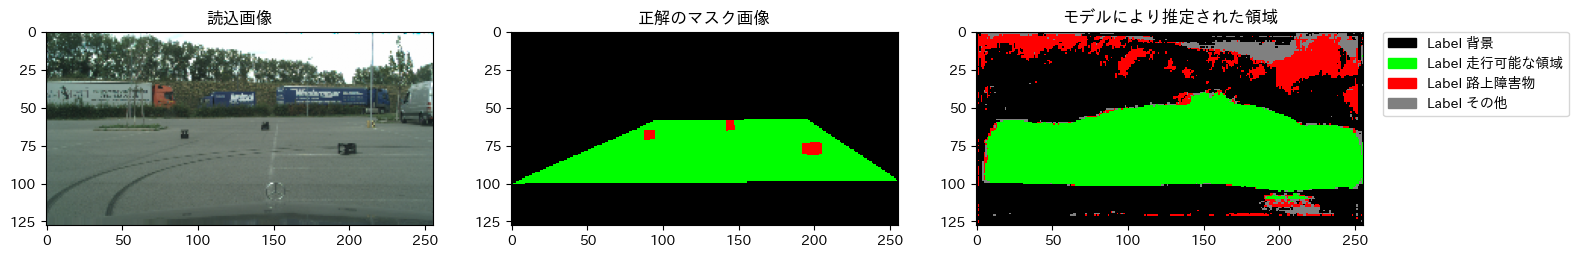


Sample Prediction after epoch 21

6/6 [==============================] - 6s 1s/step - loss: 2.6770 - iou_score: 0.3266 - val_loss: 2.8773 - val_iou_score: 0.2448
Epoch 22/100
6/6 [==============================] - 3s 675ms/step - loss: 2.6469 - iou_score: 0.3346 - val_loss: 2.8451 - val_iou_score: 0.2548
Epoch 23/100
6/6 [==============================] - 3s 652ms/step - loss: 2.6180 - iou_score: 0.3429 - val_loss: 2.8132 - val_iou_score: 0.2647
Epoch 24/100
6/6 [==============================] - 5s 884ms/step - loss: 2.5975 - iou_score: 0.3482 - val_loss: 2.8518 - val_iou_score: 0.2521
Epoch 25/100
6/6 [==============================] - 5s 990ms/step - loss: 2.5722 - iou_score: 0.3554 - val_loss: 2.8087 - val_iou_score: 0.2661
Epoch 26/100
6/6 [==============================] - 4s 690ms/step - loss: 2.5521 - iou_score: 0.3625 - val_loss: 2.7914 - val_iou_score: 0.2719
Epoch 27/100
6/6 [==============================] - 4s 838ms/step - loss: 2.5285 - iou_score: 0.3676 - val_loss: 2.84

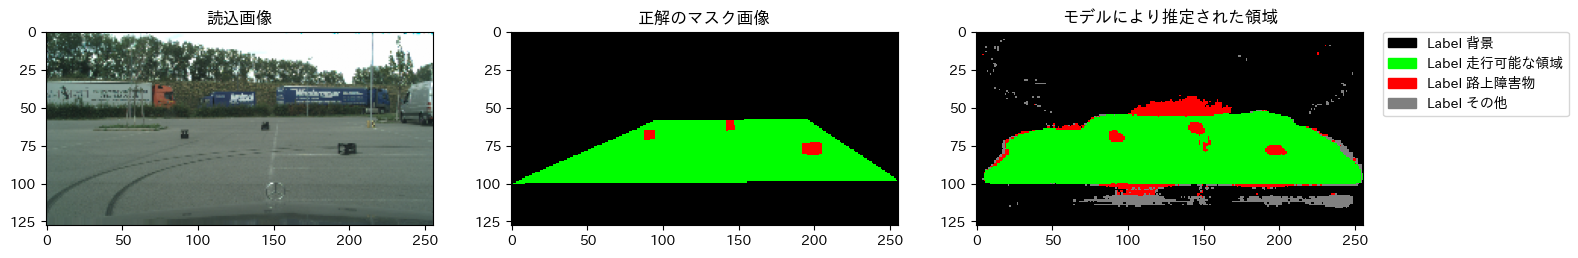


Sample Prediction after epoch 31

6/6 [==============================] - 8s 2s/step - loss: 2.4525 - iou_score: 0.3894 - val_loss: 2.7307 - val_iou_score: 0.2896
Epoch 32/100
6/6 [==============================] - 3s 624ms/step - loss: 2.4324 - iou_score: 0.3955 - val_loss: 2.6783 - val_iou_score: 0.3074
Epoch 33/100
6/6 [==============================] - 3s 615ms/step - loss: 2.4225 - iou_score: 0.3982 - val_loss: 2.6385 - val_iou_score: 0.3169
Epoch 34/100
6/6 [==============================] - 4s 874ms/step - loss: 2.4027 - iou_score: 0.4040 - val_loss: 2.6221 - val_iou_score: 0.3217
Epoch 35/100
6/6 [==============================] - 6s 1s/step - loss: 2.3878 - iou_score: 0.4089 - val_loss: 2.6528 - val_iou_score: 0.3146
Epoch 36/100
6/6 [==============================] - 6s 1s/step - loss: 2.3795 - iou_score: 0.4100 - val_loss: 2.6069 - val_iou_score: 0.3247
Epoch 37/100
6/6 [==============================] - 5s 885ms/step - loss: 2.3681 - iou_score: 0.4145 - val_loss: 2.6402 - v

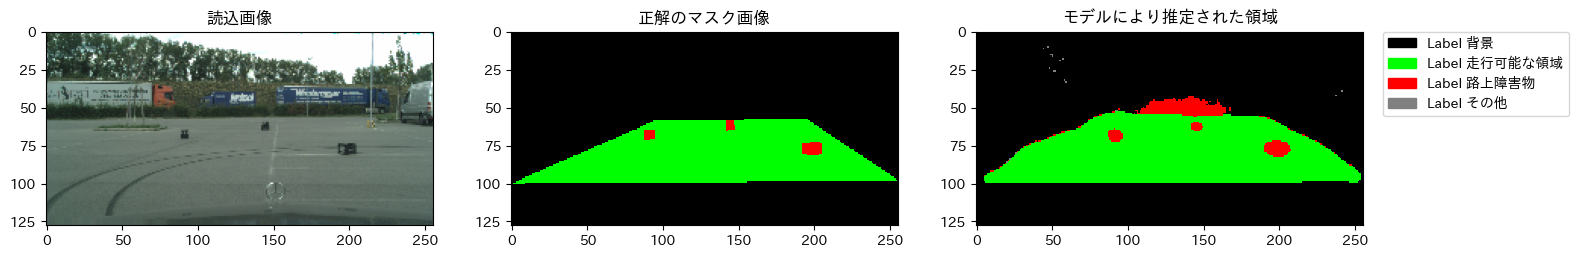


Sample Prediction after epoch 41

6/6 [==============================] - 9s 2s/step - loss: 2.3135 - iou_score: 0.4264 - val_loss: 2.5520 - val_iou_score: 0.3385
Epoch 42/100
6/6 [==============================] - 5s 953ms/step - loss: 2.3009 - iou_score: 0.4305 - val_loss: 2.5118 - val_iou_score: 0.3517
Epoch 43/100
6/6 [==============================] - 3s 649ms/step - loss: 2.2888 - iou_score: 0.4335 - val_loss: 2.5244 - val_iou_score: 0.3482
Epoch 44/100
6/6 [==============================] - 6s 1s/step - loss: 2.2673 - iou_score: 0.4381 - val_loss: 2.5215 - val_iou_score: 0.3479
Epoch 45/100
6/6 [==============================] - 5s 946ms/step - loss: 2.2602 - iou_score: 0.4401 - val_loss: 2.5409 - val_iou_score: 0.3424
Epoch 46/100
6/6 [==============================] - 4s 685ms/step - loss: 2.2546 - iou_score: 0.4420 - val_loss: 2.4872 - val_iou_score: 0.3567
Epoch 47/100
6/6 [==============================] - 4s 710ms/step - loss: 2.2391 - iou_score: 0.4451 - val_loss: 2.4868 

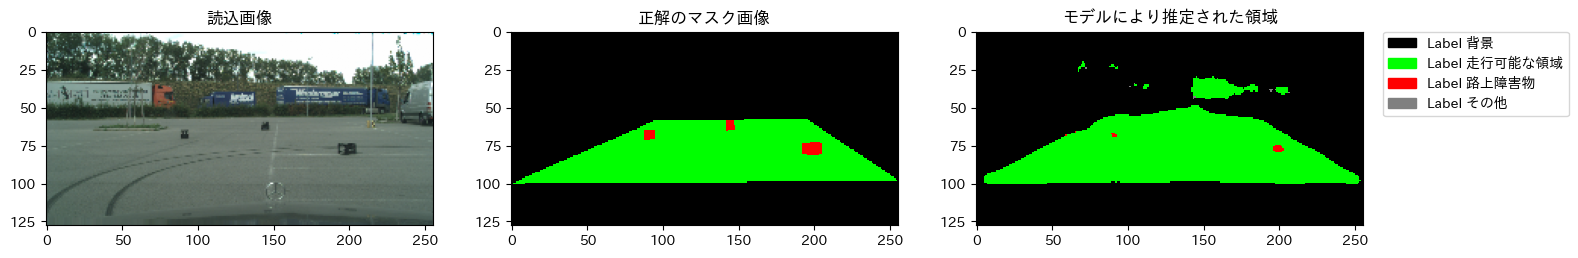


Sample Prediction after epoch 51

6/6 [==============================] - 10s 2s/step - loss: 2.2005 - iou_score: 0.4537 - val_loss: 2.4356 - val_iou_score: 0.3753
Epoch 52/100
6/6 [==============================] - 4s 687ms/step - loss: 2.1698 - iou_score: 0.4583 - val_loss: 2.4429 - val_iou_score: 0.3725
Epoch 53/100
6/6 [==============================] - 5s 997ms/step - loss: 2.1677 - iou_score: 0.4609 - val_loss: 2.4379 - val_iou_score: 0.3732
Epoch 54/100
6/6 [==============================] - 3s 662ms/step - loss: 2.1616 - iou_score: 0.4614 - val_loss: 2.4032 - val_iou_score: 0.3845
Epoch 55/100
6/6 [==============================] - 4s 734ms/step - loss: 2.1398 - iou_score: 0.4649 - val_loss: 2.4282 - val_iou_score: 0.3756
Epoch 56/100
6/6 [==============================] - 5s 974ms/step - loss: 2.1382 - iou_score: 0.4676 - val_loss: 2.3866 - val_iou_score: 0.3894
Epoch 57/100
6/6 [==============================] - 3s 650ms/step - loss: 2.1271 - iou_score: 0.4687 - val_loss: 2.3

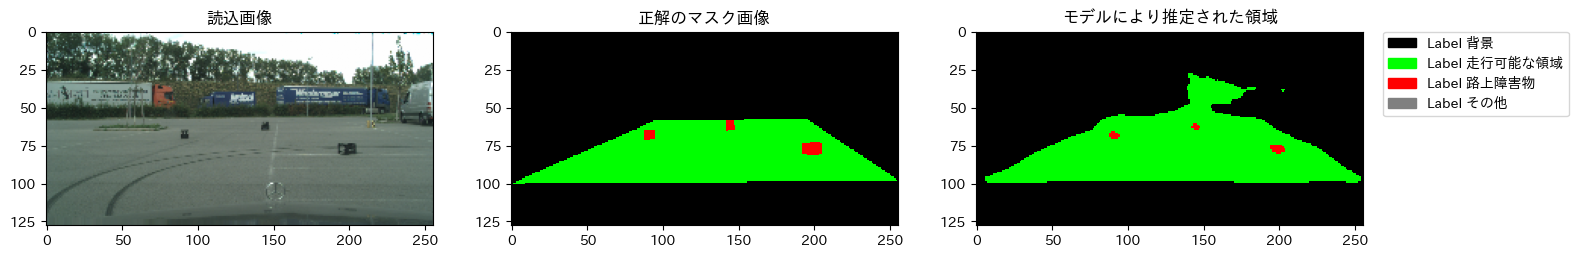


Sample Prediction after epoch 61

6/6 [==============================] - 10s 2s/step - loss: 2.0528 - iou_score: 0.4797 - val_loss: 2.3621 - val_iou_score: 0.3943
Epoch 62/100
6/6 [==============================] - 4s 706ms/step - loss: 2.0747 - iou_score: 0.4764 - val_loss: 2.3702 - val_iou_score: 0.3906
Epoch 63/100
6/6 [==============================] - 4s 737ms/step - loss: 2.0544 - iou_score: 0.4815 - val_loss: 2.3841 - val_iou_score: 0.3871
Epoch 64/100
6/6 [==============================] - 5s 969ms/step - loss: 2.0329 - iou_score: 0.4840 - val_loss: 2.3198 - val_iou_score: 0.4039
Epoch 65/100
6/6 [==============================] - 4s 730ms/step - loss: 2.0197 - iou_score: 0.4849 - val_loss: 2.2995 - val_iou_score: 0.4124
Epoch 66/100
6/6 [==============================] - 6s 1s/step - loss: 2.0062 - iou_score: 0.4864 - val_loss: 2.3479 - val_iou_score: 0.3962
Epoch 67/100
6/6 [==============================] - 4s 806ms/step - loss: 2.0088 - iou_score: 0.4871 - val_loss: 2.2724

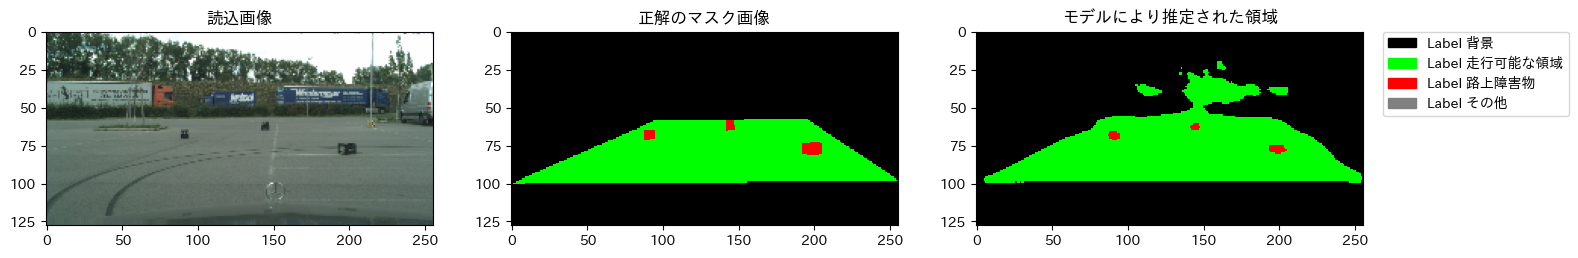


Sample Prediction after epoch 71

6/6 [==============================] - 6s 1s/step - loss: 1.9313 - iou_score: 0.4982 - val_loss: 2.3692 - val_iou_score: 0.3827
Epoch 72/100
6/6 [==============================] - 5s 976ms/step - loss: 1.9264 - iou_score: 0.5011 - val_loss: 2.3817 - val_iou_score: 0.3785
Epoch 73/100
6/6 [==============================] - 4s 683ms/step - loss: 1.9001 - iou_score: 0.5033 - val_loss: 2.3482 - val_iou_score: 0.3918
Epoch 74/100
6/6 [==============================] - 6s 1s/step - loss: 1.8886 - iou_score: 0.5116 - val_loss: 2.3360 - val_iou_score: 0.3939
Epoch 75/100
6/6 [==============================] - 6s 1s/step - loss: 1.9115 - iou_score: 0.5057 - val_loss: 2.4322 - val_iou_score: 0.3628
Epoch 76/100
6/6 [==============================] - 4s 710ms/step - loss: 1.8378 - iou_score: 0.5153 - val_loss: 2.3182 - val_iou_score: 0.3961
Epoch 77/100
6/6 [==============================] - 6s 1s/step - loss: 1.8742 - iou_score: 0.5089 - val_loss: 2.2838 - val_

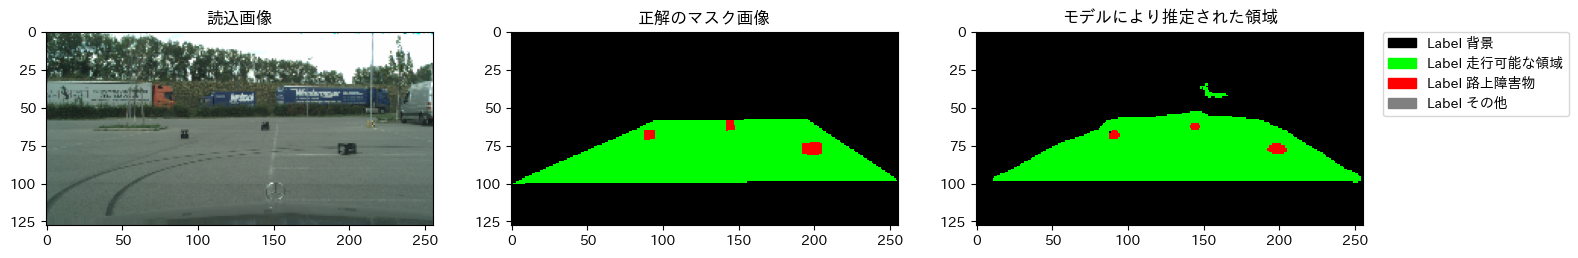


Sample Prediction after epoch 81

6/6 [==============================] - 5s 1s/step - loss: 1.7784 - iou_score: 0.5287 - val_loss: 2.1594 - val_iou_score: 0.4438
Epoch 82/100
6/6 [==============================] - 6s 1s/step - loss: 1.7968 - iou_score: 0.5226 - val_loss: 2.1780 - val_iou_score: 0.4412
Epoch 83/100
6/6 [==============================] - 6s 1s/step - loss: 1.6688 - iou_score: 0.5474 - val_loss: 2.1560 - val_iou_score: 0.4401
Epoch 84/100
6/6 [==============================] - 4s 838ms/step - loss: 1.7193 - iou_score: 0.5355 - val_loss: 2.1862 - val_iou_score: 0.4344
Epoch 85/100
6/6 [==============================] - 4s 764ms/step - loss: 1.6907 - iou_score: 0.5456 - val_loss: 2.2002 - val_iou_score: 0.4315
Epoch 86/100
6/6 [==============================] - 4s 782ms/step - loss: 1.6916 - iou_score: 0.5490 - val_loss: 2.1338 - val_iou_score: 0.4471
Epoch 87/100
6/6 [==============================] - 6s 1s/step - loss: 1.6103 - iou_score: 0.5654 - val_loss: 2.1378 - val_

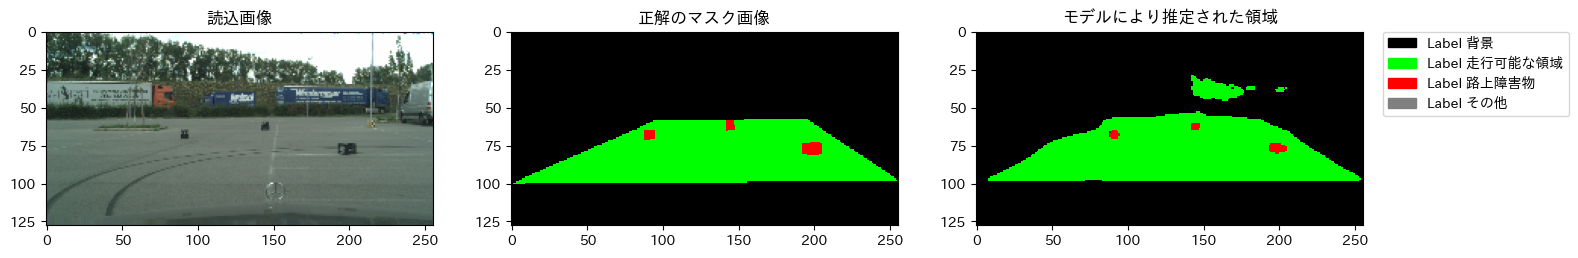


Sample Prediction after epoch 91

6/6 [==============================] - 7s 1s/step - loss: 1.6498 - iou_score: 0.5544 - val_loss: 2.1828 - val_iou_score: 0.4346
Epoch 92/100
6/6 [==============================] - 5s 990ms/step - loss: 1.5987 - iou_score: 0.5714 - val_loss: 2.0933 - val_iou_score: 0.4541
Epoch 93/100
6/6 [==============================] - 6s 1s/step - loss: 1.5549 - iou_score: 0.5836 - val_loss: 2.1353 - val_iou_score: 0.4428
Epoch 94/100
6/6 [==============================] - 4s 853ms/step - loss: 1.6091 - iou_score: 0.5706 - val_loss: 2.0503 - val_iou_score: 0.4696
Epoch 95/100
6/6 [==============================] - 4s 805ms/step - loss: 1.5079 - iou_score: 0.5939 - val_loss: 2.1006 - val_iou_score: 0.4521
Epoch 96/100
6/6 [==============================] - 4s 736ms/step - loss: 1.5099 - iou_score: 0.5860 - val_loss: 2.0544 - val_iou_score: 0.4661
Epoch 97/100
6/6 [==============================] - 4s 688ms/step - loss: 1.5376 - iou_score: 0.5889 - val_loss: 2.0576 

In [ ]:
###
#  Focal Tversky Loss (マルチクラス拡張版)
#  マスク領域の広さが不均衡なデータに対し，比較的頑健なLoss関数
###


## 15 Epoch（3分）
## 20 Epoch（4分）
## 100 Epoch (14分)

def class_tversky(y_true: tf.Tensor, y_pred: tf.Tensor):
    smooth = 1

    true_pos = tf.reduce_sum(y_true * y_pred, axis=(0, 1, 2))
    false_neg = tf.reduce_sum(y_true * (1-y_pred), axis=(0, 1, 2))
    false_pos = tf.reduce_sum((1-y_true) * y_pred, axis=(0, 1, 2))
    alpha = 0.7
    return (true_pos + smooth) / (true_pos + alpha * false_neg + (1-alpha) * false_pos + smooth)

def focal_tversky_loss(y_true: tf.Tensor, y_pred: tf.Tensor):
    pt_1 = class_tversky(y_true, y_pred)
    gamma = 0.75
    return tf.reduce_sum( (1-pt_1)**gamma )


tf.keras.backend.set_image_data_format('channels_last')


model = sm.Unet('mobilenetv2', classes=len(mask_label_to_category_name), \
                activation='softmax', encoder_weights='imagenet')

model.compile(
    tf.keras.optimizers.Adam(1.0e-4),
    loss=focal_tversky_loss,
    metrics=[sm.metrics.iou_score],
)

# 訓練中のログファイルを作成する準備
callbacks = []
callbacks.append(tf.keras.callbacks.CSVLogger('training_log.csv'))
callbacks.append(DisplayCallback(valid_dataset))

model_history = model.fit(
   x = train_dataset,
   epochs = 100,
   validation_data = valid_dataset,
   steps_per_epoch = STEPS_PER_EPOCH,
   validation_steps = VALIDATION_STEPS,
   use_multiprocessing = True,
   callbacks = callbacks
)

## モデルの評価

### 訓練済モデルによる推論

In [ ]:
train_loss, train_iou = model.evaluate(train_dataset, steps = (TRAIN_LENGTH // BATCH_SIZE) + 1, verbose=1)
print("loss (train): {:.4}".format(train_loss))
print("iou (train): {:.4}".format(train_iou))

print()

test_loss, test_iou = model.evaluate(test_dataset, steps = (TEST_LENGTH // BATCH_SIZE) + 1, verbose=1)
print("loss (test): {:.4}".format(test_loss))
print("iou (test): {:.4}".format(test_iou))

7/7 [==============================] - 5s 458ms/step - loss: 2.1192 - iou_score: 0.4493
loss (train): 2.119
iou (train): 0.4493

3/4 [=====================>........] - ETA: 0s - loss: 2.2937 - iou_score: 0.4057

4/4 [==============================] - 2s 536ms/step - loss: 2.2937 - iou_score: 0.4057
loss (test): 2.294
iou (test): 0.4057


### 損失関数と評価指標の推移

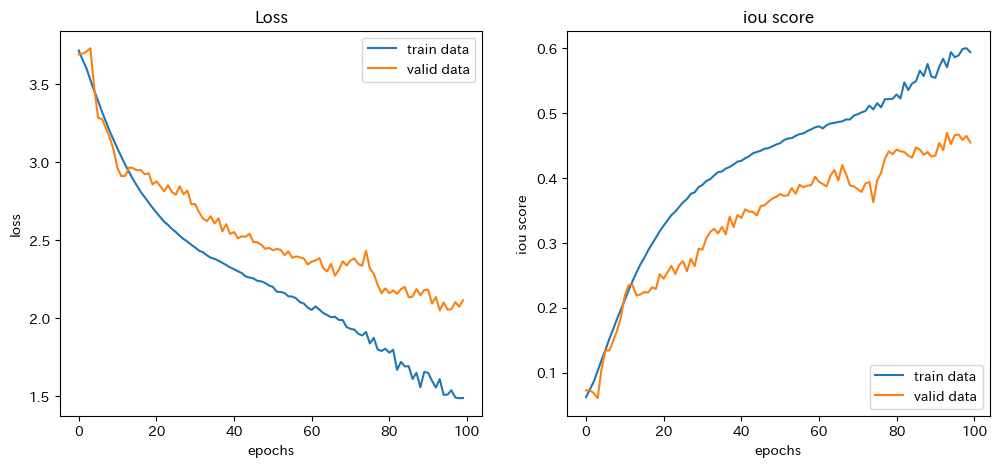

In [ ]:
log_df = pd.read_csv('training_log.csv')

epochs = log_df["epoch"].values
train_acc = log_df["iou_score"].values
train_loss = log_df["loss"].values
valid_acc = log_df["val_iou_score"].values
valid_loss = log_df["val_loss"].values

fig, axes = plt.subplots(1,2, figsize=(12,5))

axes[0].plot(epochs, train_loss, label="train data")
axes[0].plot(epochs, valid_loss, label="valid data")
axes[0].set_xlabel("epochs")
axes[0].set_ylabel("loss")
axes[0].legend(loc="upper right")
axes[0].set_title("Loss")

axes[1].plot(epochs, train_acc, label="train data")
axes[1].plot(epochs, valid_acc, label="valid data")
axes[1].set_xlabel("epochs")
axes[1].set_ylabel("iou score")
axes[1].legend(loc="lower right")
axes[1].set_title("iou score")

plt.show()

### 訓練済モデルによる推定例

1/1 [==============================] - 0s 31ms/step
[0 1]


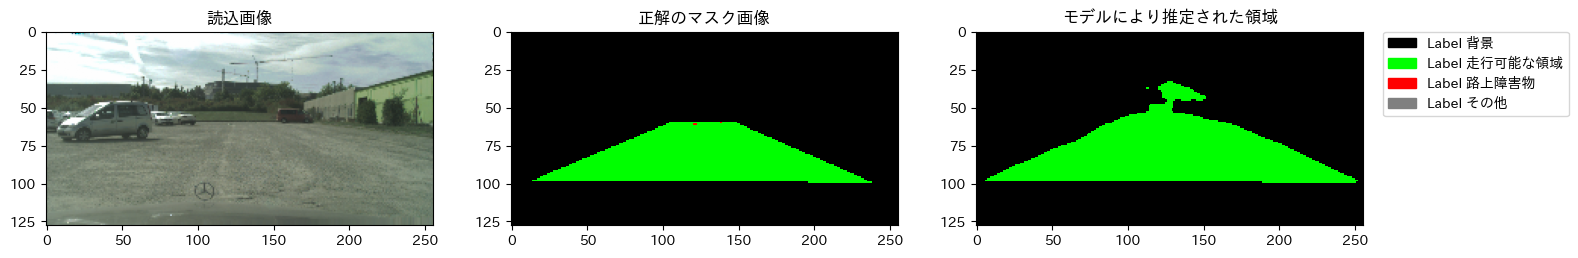

In [ ]:
# 訓練用データセット
show_predictions(train_dataset, num=1)

1/1 [==============================] - 0s 25ms/step
[0 1 2]


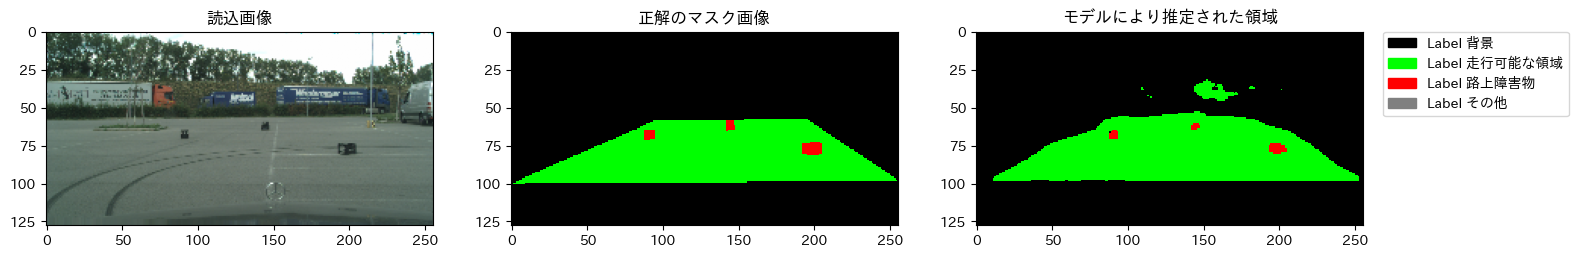

In [ ]:
# 検証用データセット
show_predictions(valid_dataset, num=1)

1/1 [==============================] - 0s 27ms/step
[0 1]


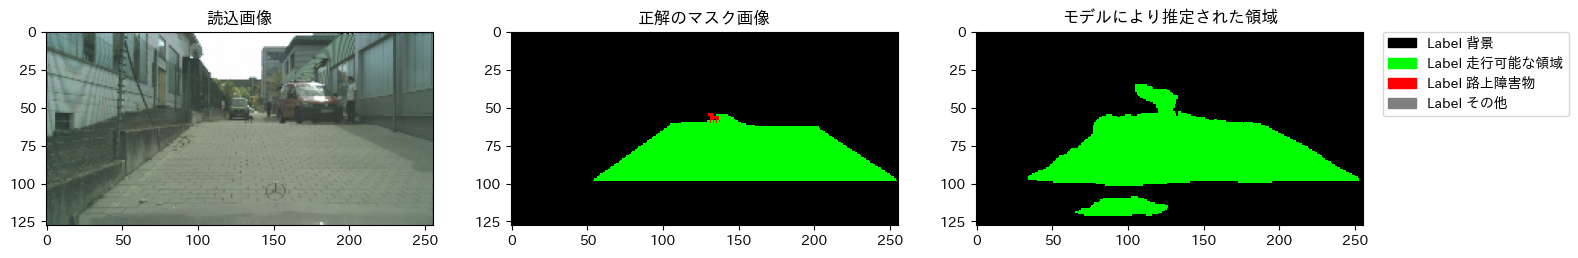

In [ ]:
# テスト用データセット
show_predictions(test_dataset, num=1)

# 課題：自分自身で撮影した画像のセグメンテーションを行う．

In [ ]:
# このコードセルを実行すると、input_images ディレクトリが作成されます．
# このディレクトリ下に画像ファイルをアップロードしてください．
!mkdir input_images


mkdir: cannot create directory ‘input_images’: File exists


In [ ]:
import tensorflow as tf
import sklearn

print('TensorFlow version:',tf.__version__)
print('scikit-learn version:',sklearn.__version__)

if tf.__version__ != '2.12.0':
    !pip install -q --upgrade tensorflow==2.12.0
    print('TensorFlow version:',tf.__version__)

if sklearn.__version__ != '1.2.2':
    !pip install -q --upgrade scikit-learn==1.2.2
    print('scikit-learn version:',sklearn.__version__)

!pip install -qU segmentation-models #セグメンテーション用のモデルを簡単に実装できるライブラリ
!pip install -q japanize_matplotlib # matplotlib日本語化用ライブラリ

TensorFlow version: 2.12.0
scikit-learn version: 1.2.2


入力画像サイズ（幅）256
入力画像サイズ（高）：128
訓練用データ数：52
検証用データ数：21
テスト用データ数：24


/usr/local/lib/python3.10/dist-packages/keras_applications/mobilenet_v2.py:294: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  warnings.warn('`input_shape` is undefined or non-square, '


Epoch 1/100
1/1 [==============================] - 1s 900ms/step
[2 3]


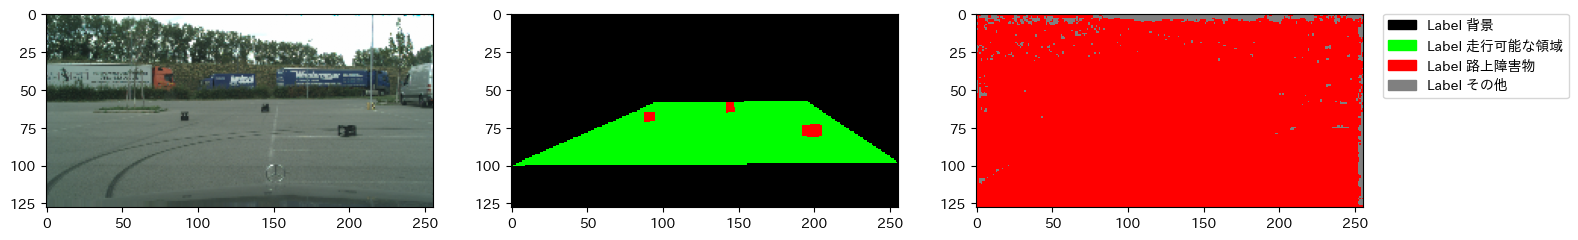


Sample Prediction after epoch 1

6/6 [==============================] - 59s 2s/step - loss: 3.5751 - iou_score: 0.0826 - val_loss: 3.9611 - val_iou_score: 0.0083
Epoch 2/100
6/6 [==============================] - 7s 1s/step - loss: 3.4708 - iou_score: 0.1030 - val_loss: 3.9596 - val_iou_score: 0.0086
Epoch 3/100
6/6 [==============================] - 6s 1s/step - loss: 3.3808 - iou_score: 0.1216 - val_loss: 3.9316 - val_iou_score: 0.0146
Epoch 4/100
6/6 [==============================] - 6s 1s/step - loss: 3.2939 - iou_score: 0.1407 - val_loss: 3.6308 - val_iou_score: 0.0745
Epoch 5/100
6/6 [==============================] - 6s 1s/step - loss: 3.2198 - iou_score: 0.1581 - val_loss: 3.4215 - val_iou_score: 0.1032
Epoch 6/100
6/6 [==============================] - 4s 700ms/step - loss: 3.1543 - iou_score: 0.1745 - val_loss: 3.4429 - val_iou_score: 0.0927
Epoch 7/100
6/6 [==============================] - 5s 969ms/step - loss: 3.1011 - iou_score: 0.1872 - val_loss: 3.4511 - val_iou_score

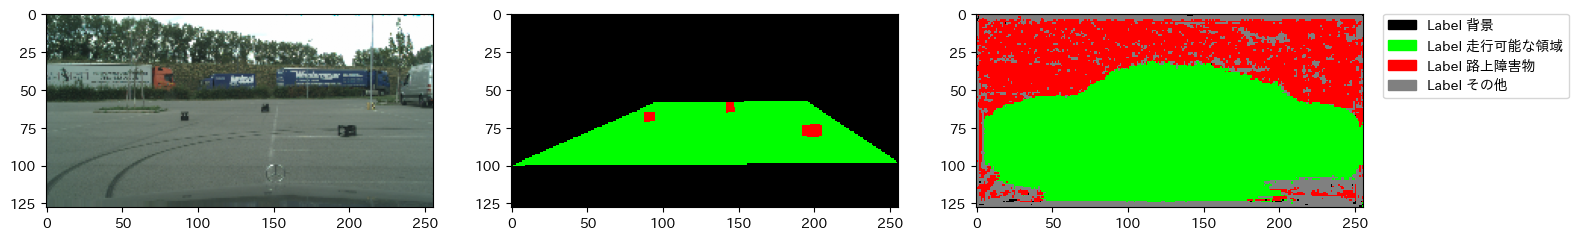


Sample Prediction after epoch 11

6/6 [==============================] - 6s 1s/step - loss: 2.9756 - iou_score: 0.2204 - val_loss: 3.3642 - val_iou_score: 0.1112
Epoch 12/100
6/6 [==============================] - 3s 614ms/step - loss: 2.9543 - iou_score: 0.2261 - val_loss: 3.3255 - val_iou_score: 0.1211
Epoch 13/100
6/6 [==============================] - 8s 1s/step - loss: 2.9225 - iou_score: 0.2363 - val_loss: 3.2777 - val_iou_score: 0.1337
Epoch 14/100
6/6 [==============================] - 3s 663ms/step - loss: 2.9043 - iou_score: 0.2426 - val_loss: 3.2422 - val_iou_score: 0.1430
Epoch 15/100
6/6 [==============================] - 7s 1s/step - loss: 2.8806 - iou_score: 0.2478 - val_loss: 3.1778 - val_iou_score: 0.1611
Epoch 16/100
6/6 [==============================] - 4s 766ms/step - loss: 2.8552 - iou_score: 0.2547 - val_loss: 3.1687 - val_iou_score: 0.1626
Epoch 17/100
6/6 [==============================] - 4s 704ms/step - loss: 2.8311 - iou_score: 0.2628 - val_loss: 3.1165 - v

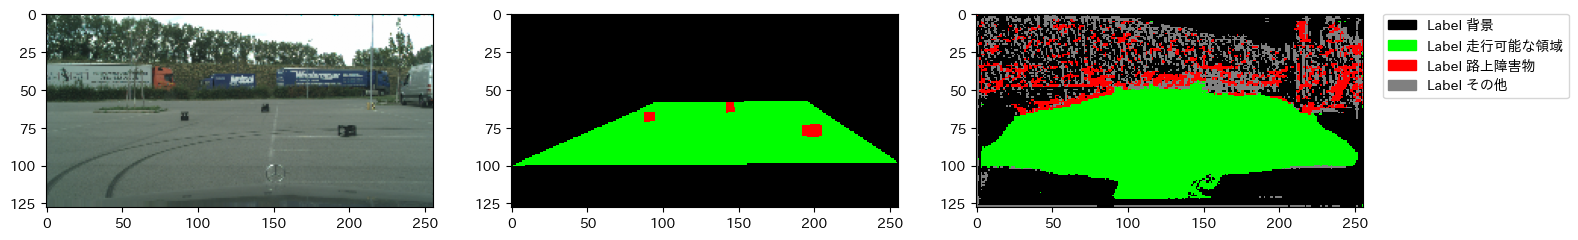


Sample Prediction after epoch 21

6/6 [==============================] - 7s 1s/step - loss: 2.7176 - iou_score: 0.2971 - val_loss: 2.9845 - val_iou_score: 0.2125
Epoch 22/100
6/6 [==============================] - 3s 656ms/step - loss: 2.6936 - iou_score: 0.3038 - val_loss: 2.9152 - val_iou_score: 0.2328
Epoch 23/100
6/6 [==============================] - 6s 1s/step - loss: 2.6655 - iou_score: 0.3130 - val_loss: 2.8830 - val_iou_score: 0.2416
Epoch 24/100
6/6 [==============================] - 3s 652ms/step - loss: 2.6443 - iou_score: 0.3191 - val_loss: 2.8294 - val_iou_score: 0.2574
Epoch 25/100
6/6 [==============================] - 3s 643ms/step - loss: 2.6228 - iou_score: 0.3252 - val_loss: 2.7972 - val_iou_score: 0.2667
Epoch 26/100
6/6 [==============================] - 5s 982ms/step - loss: 2.5968 - iou_score: 0.3339 - val_loss: 2.7550 - val_iou_score: 0.2793
Epoch 27/100
6/6 [==============================] - 4s 690ms/step - loss: 2.5749 - iou_score: 0.3413 - val_loss: 2.7174 

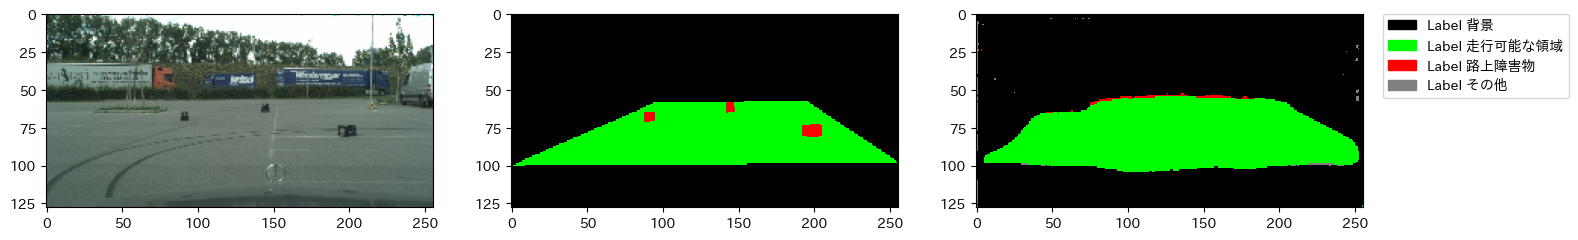


Sample Prediction after epoch 31

6/6 [==============================] - 12s 2s/step - loss: 2.4898 - iou_score: 0.3674 - val_loss: 2.6308 - val_iou_score: 0.3157
Epoch 32/100
6/6 [==============================] - 4s 691ms/step - loss: 2.4720 - iou_score: 0.3715 - val_loss: 2.5997 - val_iou_score: 0.3252
Epoch 33/100
6/6 [==============================] - 6s 1s/step - loss: 2.4538 - iou_score: 0.3777 - val_loss: 2.5762 - val_iou_score: 0.3324
Epoch 34/100
6/6 [==============================] - 3s 637ms/step - loss: 2.4317 - iou_score: 0.3846 - val_loss: 2.5773 - val_iou_score: 0.3311
Epoch 35/100
6/6 [==============================] - 3s 610ms/step - loss: 2.4208 - iou_score: 0.3880 - val_loss: 2.5621 - val_iou_score: 0.3358
Epoch 36/100
6/6 [==============================] - 4s 751ms/step - loss: 2.4003 - iou_score: 0.3931 - val_loss: 2.5583 - val_iou_score: 0.3364
Epoch 37/100
6/6 [==============================] - 6s 1s/step - loss: 2.3905 - iou_score: 0.3967 - val_loss: 2.5446 - 

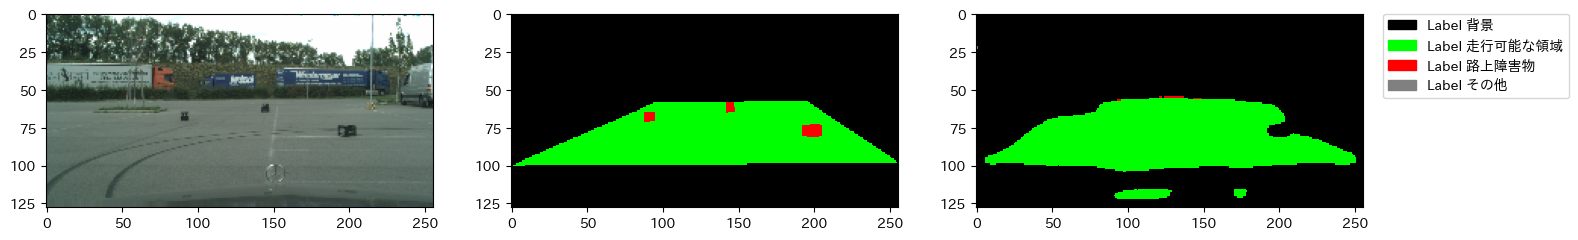


Sample Prediction after epoch 41

6/6 [==============================] - 9s 2s/step - loss: 2.3245 - iou_score: 0.4158 - val_loss: 2.4881 - val_iou_score: 0.3585
Epoch 42/100
6/6 [==============================] - 6s 1s/step - loss: 2.3110 - iou_score: 0.4202 - val_loss: 2.4636 - val_iou_score: 0.3662
Epoch 43/100
6/6 [==============================] - 6s 1s/step - loss: 2.3021 - iou_score: 0.4223 - val_loss: 2.4581 - val_iou_score: 0.3680
Epoch 44/100
6/6 [==============================] - 3s 617ms/step - loss: 2.2849 - iou_score: 0.4275 - val_loss: 2.4502 - val_iou_score: 0.3697
Epoch 45/100
6/6 [==============================] - 4s 697ms/step - loss: 2.2770 - iou_score: 0.4281 - val_loss: 2.4372 - val_iou_score: 0.3740
Epoch 46/100
6/6 [==============================] - 6s 1s/step - loss: 2.2626 - iou_score: 0.4330 - val_loss: 2.4198 - val_iou_score: 0.3780
Epoch 47/100
6/6 [==============================] - 3s 654ms/step - loss: 2.2490 - iou_score: 0.4353 - val_loss: 2.4300 - val_

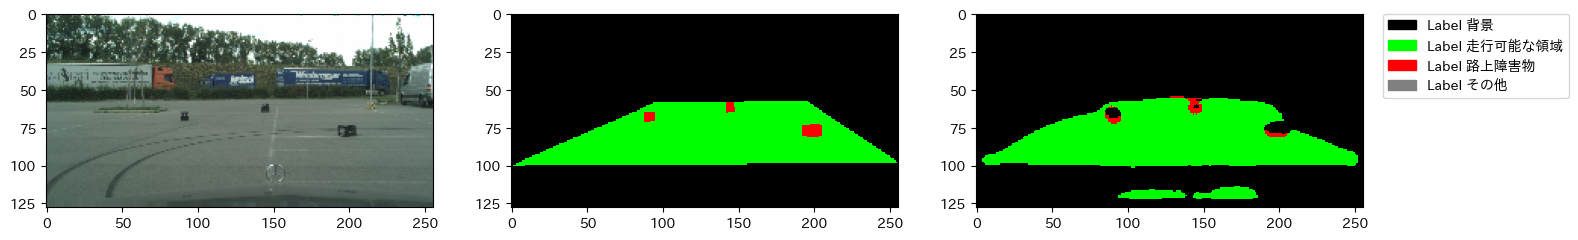


Sample Prediction after epoch 51

6/6 [==============================] - 9s 2s/step - loss: 2.1971 - iou_score: 0.4482 - val_loss: 2.3682 - val_iou_score: 0.3898
Epoch 52/100
6/6 [==============================] - 7s 1s/step - loss: 2.1893 - iou_score: 0.4488 - val_loss: 2.3554 - val_iou_score: 0.3917
Epoch 53/100
6/6 [==============================] - 3s 647ms/step - loss: 2.1602 - iou_score: 0.4536 - val_loss: 2.3587 - val_iou_score: 0.3907
Epoch 54/100
6/6 [==============================] - 6s 1s/step - loss: 2.1431 - iou_score: 0.4561 - val_loss: 2.3336 - val_iou_score: 0.3940
Epoch 55/100
6/6 [==============================] - 3s 637ms/step - loss: 2.1162 - iou_score: 0.4593 - val_loss: 2.3211 - val_iou_score: 0.3948
Epoch 56/100
6/6 [==============================] - 4s 722ms/step - loss: 2.1213 - iou_score: 0.4611 - val_loss: 2.3379 - val_iou_score: 0.3897
Epoch 57/100
6/6 [==============================] - 6s 1s/step - loss: 2.0818 - iou_score: 0.4660 - val_loss: 2.2892 - val_

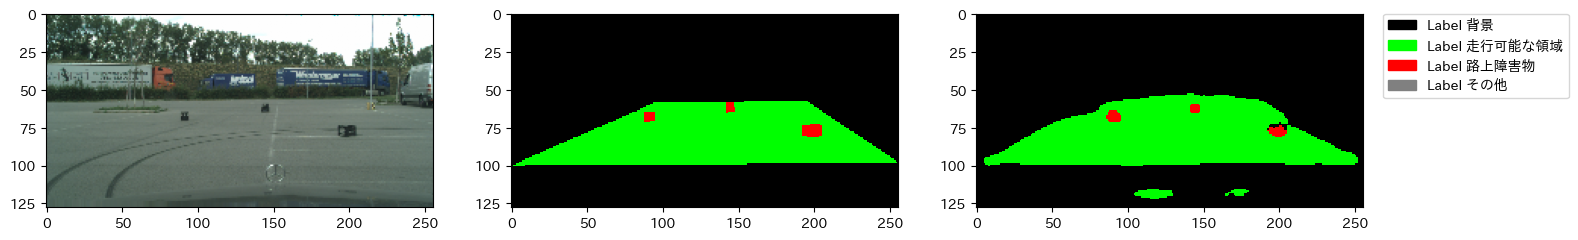


Sample Prediction after epoch 61

6/6 [==============================] - 9s 2s/step - loss: 2.0347 - iou_score: 0.4746 - val_loss: 2.2925 - val_iou_score: 0.4051
Epoch 62/100
6/6 [==============================] - 5s 988ms/step - loss: 1.9876 - iou_score: 0.4823 - val_loss: 2.2624 - val_iou_score: 0.4154
Epoch 63/100
6/6 [==============================] - 6s 1s/step - loss: 1.9727 - iou_score: 0.4867 - val_loss: 2.2227 - val_iou_score: 0.4229
Epoch 64/100
6/6 [==============================] - 5s 908ms/step - loss: 1.9357 - iou_score: 0.4938 - val_loss: 2.2358 - val_iou_score: 0.4210
Epoch 65/100
6/6 [==============================] - 4s 761ms/step - loss: 1.9417 - iou_score: 0.4900 - val_loss: 2.1975 - val_iou_score: 0.4309
Epoch 66/100
6/6 [==============================] - 4s 744ms/step - loss: 1.9301 - iou_score: 0.4957 - val_loss: 2.2057 - val_iou_score: 0.4312
Epoch 67/100
6/6 [==============================] - 6s 1s/step - loss: 1.8303 - iou_score: 0.5154 - val_loss: 2.2032 - v

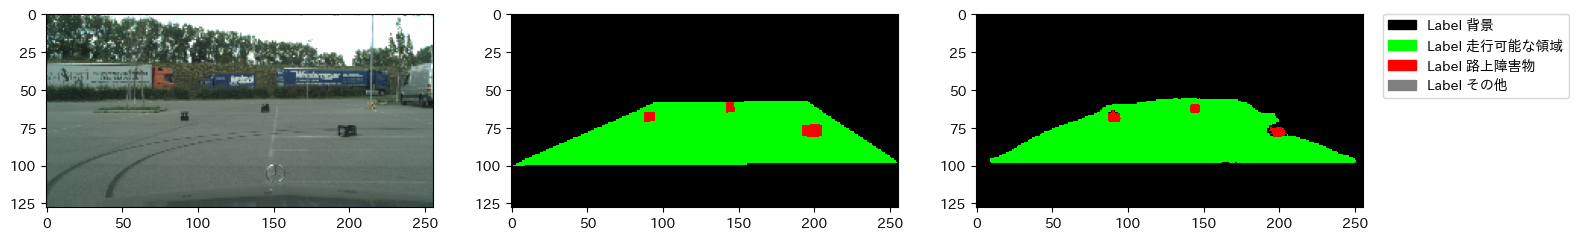


Sample Prediction after epoch 71

6/6 [==============================] - 8s 2s/step - loss: 1.7927 - iou_score: 0.5212 - val_loss: 2.1788 - val_iou_score: 0.4415
Epoch 72/100
6/6 [==============================] - 6s 1s/step - loss: 1.7907 - iou_score: 0.5254 - val_loss: 2.1970 - val_iou_score: 0.4356
Epoch 73/100
6/6 [==============================] - 6s 1s/step - loss: 1.7266 - iou_score: 0.5366 - val_loss: 2.1393 - val_iou_score: 0.4488
Epoch 74/100
6/6 [==============================] - 4s 732ms/step - loss: 1.7862 - iou_score: 0.5248 - val_loss: 2.1409 - val_iou_score: 0.4429
Epoch 75/100
6/6 [==============================] - 6s 1s/step - loss: 1.6865 - iou_score: 0.5472 - val_loss: 2.1004 - val_iou_score: 0.4532
Epoch 76/100
6/6 [==============================] - 4s 737ms/step - loss: 1.7084 - iou_score: 0.5403 - val_loss: 2.1414 - val_iou_score: 0.4459
Epoch 77/100
6/6 [==============================] - 4s 761ms/step - loss: 1.6188 - iou_score: 0.5587 - val_loss: 2.1425 - val_

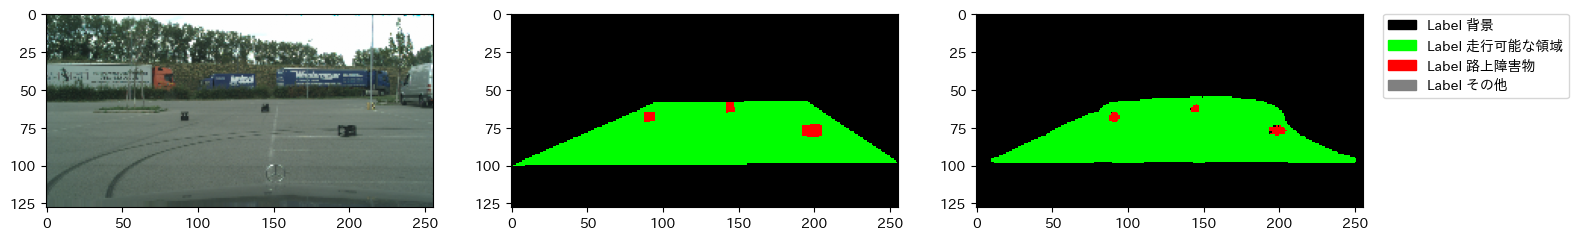


Sample Prediction after epoch 81

6/6 [==============================] - 8s 2s/step - loss: 1.4976 - iou_score: 0.5934 - val_loss: 2.1334 - val_iou_score: 0.4525
Epoch 82/100
6/6 [==============================] - 6s 1s/step - loss: 1.6005 - iou_score: 0.5626 - val_loss: 2.0967 - val_iou_score: 0.4620
Epoch 83/100
6/6 [==============================] - 6s 1s/step - loss: 1.5750 - iou_score: 0.5736 - val_loss: 2.0754 - val_iou_score: 0.4650
Epoch 84/100
6/6 [==============================] - 3s 598ms/step - loss: 1.5634 - iou_score: 0.5775 - val_loss: 2.0926 - val_iou_score: 0.4641
Epoch 85/100
6/6 [==============================] - 4s 689ms/step - loss: 1.6029 - iou_score: 0.5783 - val_loss: 2.0996 - val_iou_score: 0.4579
Epoch 86/100
6/6 [==============================] - 5s 912ms/step - loss: 1.5162 - iou_score: 0.5872 - val_loss: 2.0282 - val_iou_score: 0.4781
Epoch 87/100
6/6 [==============================] - 4s 728ms/step - loss: 1.5173 - iou_score: 0.5973 - val_loss: 2.0910 - v

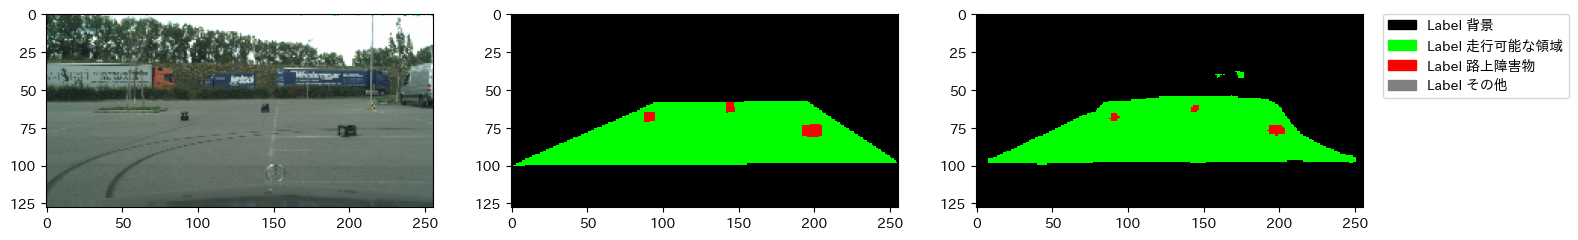


Sample Prediction after epoch 91

6/6 [==============================] - 9s 2s/step - loss: 1.4457 - iou_score: 0.6109 - val_loss: 2.1040 - val_iou_score: 0.4610
Epoch 92/100
6/6 [==============================] - 4s 742ms/step - loss: 1.4306 - iou_score: 0.6211 - val_loss: 2.0349 - val_iou_score: 0.4761
Epoch 93/100
6/6 [==============================] - 3s 606ms/step - loss: 1.5040 - iou_score: 0.5923 - val_loss: 2.0987 - val_iou_score: 0.4617
Epoch 94/100
6/6 [==============================] - 6s 1s/step - loss: 1.4836 - iou_score: 0.6070 - val_loss: 2.0223 - val_iou_score: 0.4813
Epoch 95/100
6/6 [==============================] - 3s 579ms/step - loss: 1.4512 - iou_score: 0.6151 - val_loss: 2.0635 - val_iou_score: 0.4724
Epoch 96/100
6/6 [==============================] - 3s 631ms/step - loss: 1.4247 - iou_score: 0.6260 - val_loss: 2.0434 - val_iou_score: 0.4775
Epoch 97/100
6/6 [==============================] - 6s 1s/step - loss: 1.3978 - iou_score: 0.6283 - val_loss: 2.0624 - v

In [ ]:
import os # os：標準ライブラリ，OS依存の処理（環境変数やフォルダ作成など）を扱う
import datetime # datetime：標準ライブラリ，日付関連データを扱う
import random # random：標準ライブラリ，擬似乱数発生器
import numpy as np # numpy：数値計算用ライブラリの一つ
import pandas as pd # pandas：表計算用ライブラリの一つ
from IPython.display import display # Colabなどで一部のデータをprint()よりも綺麗に出力できる関数
import glob # glob:パスを扱う標準ライブラリ

import matplotlib.pylab as plt # matplotlib：グラフ描画用ライブラリの一つ
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

import seaborn as sns # seaborn：グラフ描画用ライブラリの一つ
# tensorboard：深層学習ライブラリTensorFlowのダッシュボード出力用設定
#%load_ext tensorboard
import tensorflow as tf # TensorFlow：深層学習ライブラリ一つ

import japanize_matplotlib # matplotlib日本語化用の外部ライブラリ

import tensorflow_datasets as tfds # TensoFlow datasets TensorFlow が提供するデータセット群が纏められたライブラリ
os.environ["SM_FRAMEWORK"] = "tf.keras" # segmentation_modelsで使用するライブラリをTensorFlow内蔵のKerasとする
import segmentation_models as sm #セグメンテーション用のモデルを簡単に実装できるライブラリ



# 10分
dataset, info = tfds.load('lost_and_found:1.*.*', split={'train':'train[:5%]','valid':'train[5%:7%]','test':'test[:2%]'}, with_info=True)



# 使用する画像サイズ
IMG_SIZE_WIDTH = 256 # 元画像は2048
IMG_SIZE_HEIGHT = 128 # 元画像は1024

TRAIN_LENGTH = dataset['train'].cardinality().numpy()
VALID_LENGTH = dataset['valid'].cardinality().numpy()
TEST_LENGTH = dataset['test'].cardinality().numpy()

BATCH_SIZE = 8
BUFFER_SIZE = 10
STEPS_PER_EPOCH = TRAIN_LENGTH // BATCH_SIZE
VALIDATION_STEPS = VALID_LENGTH // BATCH_SIZE

# 数値ラベルと種別名の対応を定義
mask_label_to_category_name = {
    0 : '背景',
    1 : '走行可能な領域',
    2 : '路上障害物',
    3 : 'その他'
}

@tf.function
def mapping(x):
    ###
    # 簡略化のための正解ラベル調整
    ###

    # Standard objects（物体）,
    # Random hazards（走行上危険な異物）, Random non-hazards（走行上危険ではない異物）
    # Emotional hazards（精神上危険な異物 例：犬/猫）, humans（人）
    #  -> これらを一括して「路上障害物」の扱いとする
    x = tf.where( ( ( x >= 2 ) & ( x <= 43) ), 2, x)

    # miscellaneous (その他)
    x = tf.where( ( x>=255 )&( x<=255 ), 3, x)

    return x

def normalize(input_image, input_mask):

    input_image = tf.cast(input_image, tf.float32) / 255.0
    input_mask = tf.cast(input_mask, tf.int32)

    input_mask = tf.map_fn(fn=mapping, elems=input_mask, fn_output_signature=tf.int32)

    input_mask = tf.reshape(tensor = tf.one_hot(tf.cast(input_mask, tf.int32), depth=len(mask_label_to_category_name), axis=3), \
                            shape = (IMG_SIZE_HEIGHT, IMG_SIZE_WIDTH, len(mask_label_to_category_name)))

    return input_image, input_mask


def load_image(datapoint):

    input_image = tf.image.resize(images = datapoint['image_left'],
                                size = (IMG_SIZE_HEIGHT, IMG_SIZE_WIDTH),
                                method=tf.image.ResizeMethod.BILINEAR
                                )


    input_mask = tf.image.resize(images = datapoint['segmentation_label'],
                                size = (IMG_SIZE_HEIGHT, IMG_SIZE_WIDTH),
                                antialias=False, # NEAREST_NEIGHBOR の場合は無効
                                # A deterministic GPU implementation of ResizeNearestNeighborGrad is not currently available.
                                method=tf.image.ResizeMethod.NEAREST_NEIGHBOR
                                #method=tf.image.ResizeMethod.BILINEAR #(maskには不適な補間)
                                #method=tf.image.ResizeMethod.BICUBIC #(maskには不適な補間)
                                #method=tf.image.ResizeMethod.AREA #(maskには不適な補間)
                                )

    input_image, input_mask = normalize(input_image, input_mask)
    return input_image, input_mask



train_images = dataset['train'].map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
valid_images = dataset['valid'].map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
test_images = dataset['test'].map(load_image, num_parallel_calls=tf.data.AUTOTUNE)

print(f'入力画像サイズ（幅）{IMG_SIZE_WIDTH}')
print(f'入力画像サイズ（高）：{IMG_SIZE_HEIGHT}')

print(f'訓練用データ数：{TRAIN_LENGTH}')
print(f'検証用データ数：{VALID_LENGTH}')
print(f'テスト用データ数：{TEST_LENGTH}')


class Augment(tf.keras.layers.Layer):
  def __init__(self, seed=42):
    super().__init__()
    # both use the same seed, so they'll make the same random changes.
    self.augment_inputs = tf.keras.layers.RandomFlip(mode="horizontal", seed=seed)
    self.augment_labels = tf.keras.layers.RandomFlip(mode="horizontal", seed=seed)

  def call(self, inputs, labels):
    inputs = self.augment_inputs(inputs)
    labels = self.augment_labels(labels)
    return inputs, labels



train_dataset = (
    train_images
    #.cache()
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE)
    .repeat()
    .map(Augment())
    .prefetch(buffer_size=tf.data.AUTOTUNE))

valid_dataset = valid_images.batch(BATCH_SIZE).repeat()
test_dataset = test_images.batch(BATCH_SIZE)


# 描画用関数

def create_mask(pred_mask, n=0):
    pred_mask = tf.argmax(pred_mask, axis=-1)
    pred_mask = pred_mask[..., tf.newaxis]
    return pred_mask[n]


def show_predictions(dataset, num=1):

    colors = ['black', 'lime', 'red', 'gray']
    cmap = ListedColormap(colors, name="custom")
    cmap.set_bad('yellow') #無効な値が出力された場合
    values = range(len(mask_label_to_category_name))

    for image, true_mask in dataset.take(1):
        for n in range(num):

            fig, axes = plt.subplots(1, 3, figsize=(17,10))
            axes[0].imshow(image[n])
            axes[1].imshow(create_mask(true_mask, n=n), interpolation='none', \
                          cmap=cmap, vmin = np.min(values), vmax = np.max(values))

            predict_mask = create_mask( model.predict(image), n=n )
            axes[2].imshow(predict_mask, interpolation='none', \
                                cmap=cmap, vmin = np.min(values), vmax = np.max(values))

            print(np.unique(predict_mask.numpy().ravel()))

            patches = [ mpatches.Patch(color=colors[i], \
                                        label="Label {l}".format(l=mask_label_to_category_name[i]) ) for i in range(len(values)) ]

            plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0. )
            plt.show()


class DisplayCallback(tf.keras.callbacks.Callback):

    def __init__(self, validation_dataset):
        super().__init__()
        self.validation_data = validation_dataset

    def on_epoch_end(self, epoch, logs):
        # 10 Epoch毎に推論画像を出力する
        if (epoch % 10 == 0) :
            show_predictions(self.validation_data)
            print('\nSample Prediction after epoch {}\n'.format(epoch+1))


###
#  Focal Tversky Loss (multi-class)
#  マスク領域の広さが不均衡なデータに頑健なLoss関数
###


## 15 Epoch（3分）
## 20 Epoch（4分）
## 100 Epoch (14分)

def class_tversky(y_true: tf.Tensor, y_pred: tf.Tensor):
    smooth = 1

    true_pos = tf.reduce_sum(y_true * y_pred, axis=(0, 1, 2))
    false_neg = tf.reduce_sum(y_true * (1-y_pred), axis=(0, 1, 2))
    false_pos = tf.reduce_sum((1-y_true) * y_pred, axis=(0, 1, 2))
    alpha = 0.7
    return (true_pos + smooth) / (true_pos + alpha * false_neg + (1-alpha) * false_pos + smooth)

def focal_tversky_loss(y_true: tf.Tensor, y_pred: tf.Tensor):
    pt_1 = class_tversky(y_true, y_pred)
    gamma = 0.75
    return tf.reduce_sum( (1-pt_1)**gamma )



tf.keras.backend.set_image_data_format('channels_last')

model = sm.Unet('mobilenetv2', classes=len(mask_label_to_category_name), \
                activation='softmax', encoder_weights='imagenet')

model.compile(
    tf.keras.optimizers.Adam(1.0e-4),
    loss=focal_tversky_loss,
    metrics=[sm.metrics.iou_score],
)

# 訓練中のログファイルを作成する準備
callbacks = []
callbacks.append(tf.keras.callbacks.CSVLogger('training_log.csv'))
callbacks.append(DisplayCallback(valid_dataset))

model_history = model.fit(
   x = train_dataset,
   epochs = 100,
   validation_data = valid_dataset,
   steps_per_epoch = STEPS_PER_EPOCH,
   validation_steps = VALIDATION_STEPS,
   use_multiprocessing = True,
   callbacks = callbacks
)

7/7 [==============================] - 5s 472ms/step - loss: 2.0517 - iou_score: 0.4739
loss (train): 2.052
iou (train): 0.4739

3/4 [=====================>........] - ETA: 0s - loss: 2.2467 - iou_score: 0.4237

4/4 [==============================] - 3s 650ms/step - loss: 2.2467 - iou_score: 0.4237
loss (test): 2.247
iou (test): 0.4237


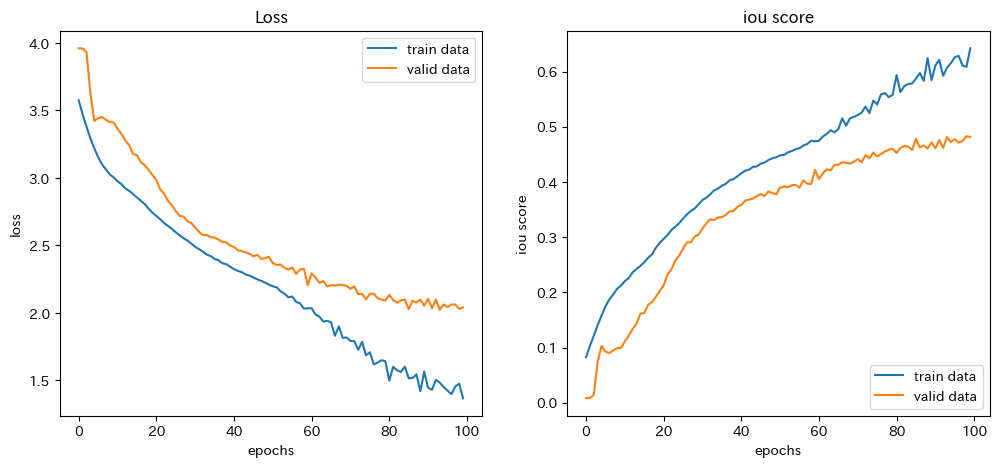

In [ ]:
train_loss, train_iou = model.evaluate(train_dataset, steps = (TRAIN_LENGTH // BATCH_SIZE) + 1, verbose=1)
print("loss (train): {:.4}".format(train_loss))
print("iou (train): {:.4}".format(train_iou))

print()

test_loss, test_iou = model.evaluate(test_dataset, steps = (TEST_LENGTH // BATCH_SIZE) + 1, verbose=1)
print("loss (test): {:.4}".format(test_loss))
print("iou (test): {:.4}".format(test_iou))


log_df = pd.read_csv('training_log.csv')

epochs = log_df["epoch"].values
train_acc = log_df["iou_score"].values
train_loss = log_df["loss"].values
valid_acc = log_df["val_iou_score"].values
valid_loss = log_df["val_loss"].values

fig, axes = plt.subplots(1,2, figsize=(12,5))

axes[0].plot(epochs, train_loss, label="train data")
axes[0].plot(epochs, valid_loss, label="valid data")
axes[0].set_xlabel("epochs")
axes[0].set_ylabel("loss")
axes[0].legend(loc="upper right")
axes[0].set_title("Loss")

axes[1].plot(epochs, train_acc, label="train data")
axes[1].plot(epochs, valid_acc, label="valid data")
axes[1].set_xlabel("epochs")
axes[1].set_ylabel("iou score")
axes[1].legend(loc="lower right")
axes[1].set_title("iou score")

plt.savefig('loss.jpeg')
plt.show()

Found 3 files belonging to 1 classes.
読み込んだ画像枚数：3
(1, 128, 256, 3)
1/1 [==============================] - 1s 1s/step
[0 1]


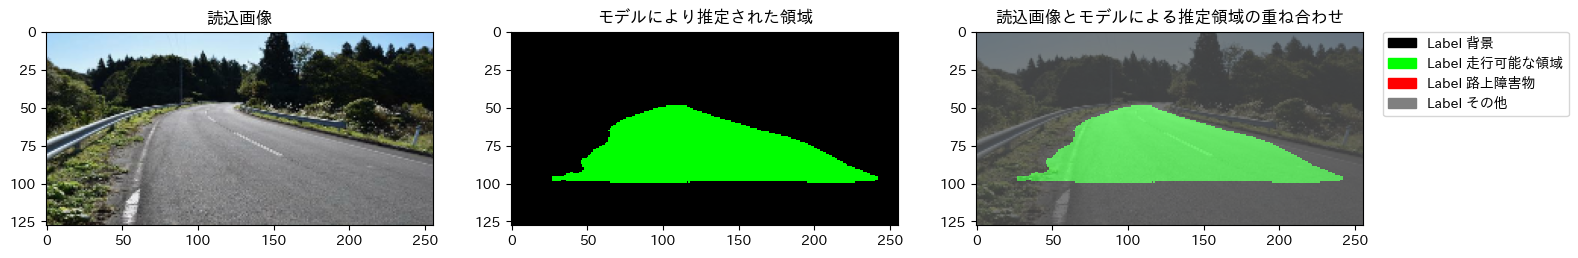

(1, 128, 256, 3)
1/1 [==============================] - 0s 50ms/step
[0 1]


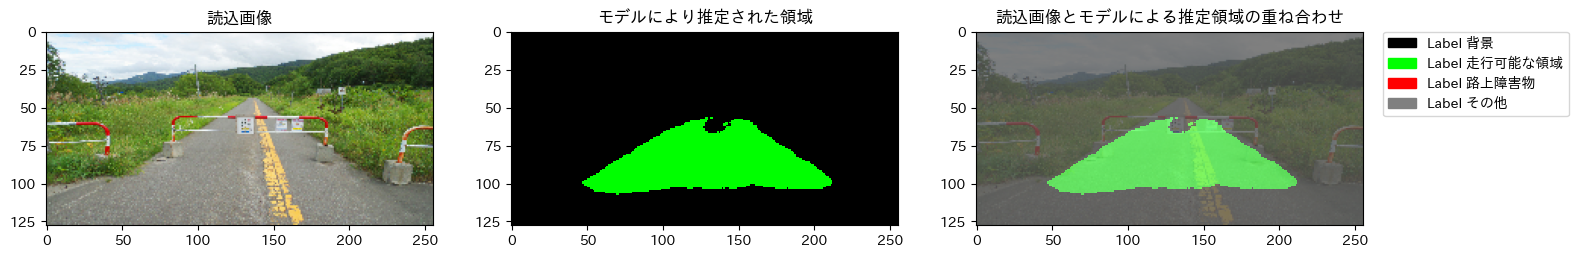

(1, 128, 256, 3)
1/1 [==============================] - 0s 52ms/step
[0 1 2]


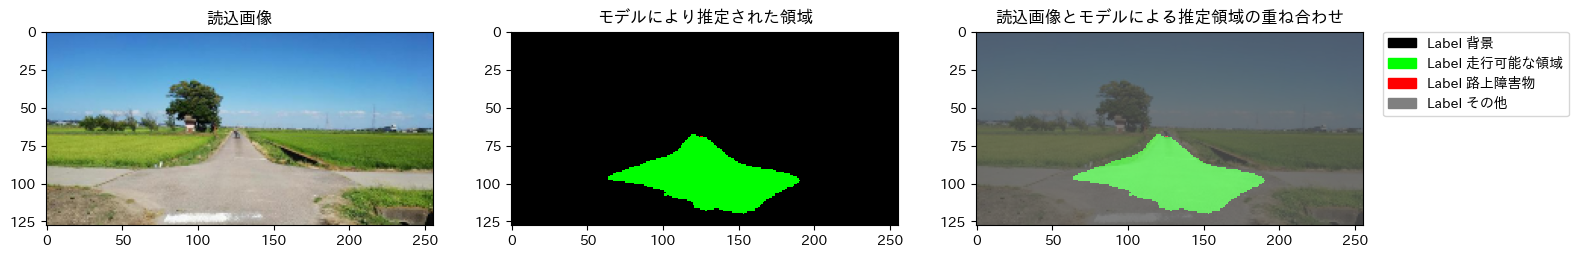

In [ ]:
if not os.path.isdir('/content/input_images'):
    raise ValueError("input_images ディレクトリを作成し，その中に画像をアップロードしてください。")


for filepath in glob.glob('/content/input_images/*'):

    extension = (os.path.splitext(filepath)[1]).lower()
    if (extension != '.jpeg')and(extension != '.jpg')and( extension != '.png' ) and ( extension != '.bmp' ):
        # PNG, JPEG, BMP 形式以外のファイルを削除
        os.remove(filepath)

if (len(glob.glob('/content/input_images/*')) < 1 ) :
    raise ValueError("input_images ディレクトリ中に、PNG/JPEG/BMP形式の内いずれかの画像ファイルをアップロードしてください。")



road_dataset = tf.keras.utils.image_dataset_from_directory(
    directory = '/content/input_images',
    labels=None,
    label_mode=None,
    class_names=None,
    color_mode='rgb',
    batch_size=1,
    image_size=(IMG_SIZE_HEIGHT, IMG_SIZE_WIDTH),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation='bilinear',
    follow_links=False,
    crop_to_aspect_ratio=False,
)


ROAD_LENGTH = road_dataset.cardinality().numpy()
print(f'読み込んだ画像枚数：{ROAD_LENGTH}')

colors = ['black', 'lime', 'red', 'gray']
cmap = ListedColormap(colors, name="custom")
cmap.set_bad('yellow') #無効な値が出力された場合
values = range(len(mask_label_to_category_name))


for idx, image in enumerate( road_dataset.take(ROAD_LENGTH) ) :

    print(image.shape)

    fig, axes = plt.subplots(1, 3, figsize=(17,10))
    axes[0].imshow(tf.cast(image[0,:,:,:],tf.uint8))
    axes[0].set_title('読込画像')

    predict_mask = create_mask( model.predict( image/255 ), n = 0 )
    axes[1].imshow(predict_mask, interpolation='none', \
                        cmap=cmap, vmin = np.min(values), vmax = np.max(values))
    axes[1].set_title('モデルにより推定された領域')

    axes[2].imshow(tf.cast(image[0,:,:,:],tf.uint8), alpha = 0.5)
    axes[2].imshow(predict_mask, interpolation='none', \
                        cmap=cmap, vmin = np.min(values), vmax = np.max(values), alpha = 0.5)
    axes[2].set_title('読込画像とモデルによる推定領域の重ね合わせ')

    print(np.unique(predict_mask.numpy().ravel()))

    patches = [ mpatches.Patch(color=colors[i], \
                                label="Label {l}".format(l=mask_label_to_category_name[i]) ) for i in range(len(values)) ]

    plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0. )
    plt.savefig(f'prediction_mask_image_{idx}.jpeg')
    plt.show()